<a href="https://colab.research.google.com/github/victoria-analyst/Exploratory-Data-Analysis-for-an-International-E-commerce-Company/blob/main/Python_for_DA_Module_Task.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Завантаження та опис даних

У датасеті міститься інформація щодо продажів продукції компанії, яка працює на світовому ринку і продає товари у звичайних магазинах та інтернет-магазинах.

Датасет складається з трьох таблиць:

**events.csv** — продажі за декілька років;  
**products.csv** — категорії товарів та їх коди;  
**countries.csv** — країни, регіони та їх коди.

Нижче наведений опис кожної з цих таблиць.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import seaborn as sns

from google.colab import drive
drive.mount("/content/drive")

%cd /content/drive/MyDrive/Mate_Python/Final_project

events = pd.read_csv("events.csv")
events.head()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
/content/drive/MyDrive/Mate_Python/Final_project


,Order ID,Order Date,Ship Date,Order Priority,Country Code,Product ID,Sales Channel,Units Sold,Unit Price,Unit Cost
0,100640618,10/8/2014,10/18/2014,M,NOR,2103,Online,650.0,205.70,117.11
1,100983083,8/11/2016,8/11/2016,C,SRB,2103,Offline,1993.0,205.70,117.11
2,101025998,7/18/2014,8/11/2014,M,NaN,7940,Online,4693.0,668.27,502.54
3,102230632,5/13/2017,6/13/2017,L,MNE,2455,Online,1171.0,109.28,35.84
4,103435266,8/11/2012,9/18/2012,H,SRB,1270,Offline,7648.0,47.45,31.79


In [ ]:
# опис даних таблиці events

events.columns = events.columns.str.lower().str.replace(" ", "_")
events.head()


,order_id,order_date,ship_date,order_priority,country_code,product_id,sales_channel,units_sold,unit_price,unit_cost
0,100640618,10/8/2014,10/18/2014,M,NOR,2103,Online,650.0,205.70,117.11
1,100983083,8/11/2016,8/11/2016,C,SRB,2103,Offline,1993.0,205.70,117.11
2,101025998,7/18/2014,8/11/2014,M,NaN,7940,Online,4693.0,668.27,502.54
3,102230632,5/13/2017,6/13/2017,L,MNE,2455,Online,1171.0,109.28,35.84
4,103435266,8/11/2012,9/18/2012,H,SRB,1270,Offline,7648.0,47.45,31.79


`order_id` - ідентифікатор замовлення  
`order_date` - дата створення (оформлення) замовлення  
`ship_date` - дата відправлення замовлення клієнту  
`order_priority` - пріоритет замовлення (L - Low (низький), M - Medium (середній), H - High (високий), C - Critical(критичний))  
`country_code` -  трилітерний код країни (ISO З166-1 Alpha-З)  
`product_id` - ідентифікатор продукту   
`sales_channel` - канал продажу (онлайн/офлайн)  
`units_sold` - кількість проданих одиниць у межах замовлення  
`unit_price` - ціна одиниці продукції  
`unit_cost` - собівартість одиниці продукції

In [ ]:
# опис даних таблиці products

products = pd.read_csv("products.csv")
products = products.rename(columns={"id": "product_id"})
products.head()

,product_id,item_type
0,2103,Cereal
1,7940,Household
2,2455,Clothes
3,1270,Beverages
4,8681,Office Supplies


`product_id`- ідентифікатор продукту  
`item_type` - тип товару

In [ ]:
# опис даних таблиці countries

countries = pd.read_csv("countries.csv")
countries.columns = countries.columns.str.replace("-", "_")
countries.head()

,name,alpha_2,alpha_3,region,sub_region
0,Afghanistan,AF,AFG,Asia,Southern Asia
1,Åland Islands,AX,ALA,Europe,Northern Europe
2,Albania,AL,ALB,Europe,Southern Europe
3,Algeria,DZ,DZA,Africa,Northern Africa
4,American Samoa,AS,ASM,Oceania,Polynesia


`name` - назва країни  
`alpha_2` - дволітерний код країни (ISO З166-1 Alpha-2)	  
`alpha_3` - трилітерний код країни ((ISO З166-1 Alpha-З)	  
`region` - регіон  
`sub_region` - субрегіон

#Огляд даних. Перетворення даних та перевірка якості

In [ ]:
# огляд даних таблиці events
events.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1330 entries, 0 to 1329
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   order_id        1330 non-null   int64  
 1   order_date      1330 non-null   object 
 2   ship_date       1330 non-null   object 
 3   order_priority  1330 non-null   object 
 4   country_code    1248 non-null   object 
 5   product_id      1330 non-null   int64  
 6   sales_channel   1330 non-null   object 
 7   units_sold      1328 non-null   float64
 8   unit_price      1330 non-null   float64
 9   unit_cost       1330 non-null   float64
dtypes: float64(3), int64(2), object(5)
memory usage: 104.0+ KB


In [ ]:
# пропущені значення в таблиці events

print(events.isna().sum())
print(f"\n")
print(events.isna().sum() / events.shape[0] * 100)

order_id           0
order_date         0
ship_date          0
order_priority     0
country_code      82
product_id         0
sales_channel      0
units_sold         2
unit_price         0
unit_cost          0
dtype: int64


order_id          0.000000
order_date        0.000000
ship_date         0.000000
order_priority    0.000000
country_code      6.165414
product_id        0.000000
sales_channel     0.000000
units_sold        0.150376
unit_price        0.000000
unit_cost         0.000000
dtype: float64


units_sold - ключова метрика, необхідна для розрахунків. Заповнення пропущених значень середнім, медіаною або нулем спотворить аналітику.  

Оскільки рядків із NaN **units_sold** всього лиш 2 із 1330, тобто 0,15%, **видалимо** їх.

Видаляти рядки із пропущеним кодом країни (country_code) не доцільно: їх багато - 82, тобто близько 6%. Окрім цього, це додаткова інформація, відсутність якої не впливає на розрахунки.

Тому просто замінимо невідомі значення **country_code** на **"Unknown"**.

In [ ]:
events = events.dropna(subset=["units_sold"])
events["country_code"] = events["country_code"].fillna("Unknown")
print(events.shape)
events

(1328, 10)


,order_id,order_date,ship_date,order_priority,country_code,product_id,sales_channel,units_sold,unit_price,unit_cost
0,100640618,10/8/2014,10/18/2014,M,NOR,2103,Online,650.0,205.70,117.11
1,100983083,8/11/2016,8/11/2016,C,SRB,2103,Offline,1993.0,205.70,117.11
2,101025998,7/18/2014,8/11/2014,M,Unknown,7940,Online,4693.0,668.27,502.54
3,102230632,5/13/2017,6/13/2017,L,MNE,2455,Online,1171.0,109.28,35.84
4,103435266,8/11/2012,9/18/2012,H,SRB,1270,Offline,7648.0,47.45,31.79
...,...,...,...,...,...,...,...,...,...,...
1325,994504153,1/10/2017,1/13/2017,M,SWE,4594,Online,4734.0,9.33,6.92
1326,994978797,12/5/2014,1/2/2015,H,ITA,1270,Offline,5192.0,47.45,31.79
1327,996754205,9/20/2010,9/22/2010,L,RUS,7331,Offline,574.0,255.28,159.42
1328,998043382,6/15/2010,7/3/2010,H,MLT,8293,Online,2070.0,437.20,263.33


In [ ]:
# огляд даних таблиці products
products.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12 entries, 0 to 11
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   product_id  12 non-null     int64 
 1   item_type   12 non-null     object
dtypes: int64(1), object(1)
memory usage: 324.0+ bytes


In [ ]:
# робота з пропущеними значеннями в таблиці products

print(products.isna().sum())
print(f"\n")
print(products.isna().sum() / products.shape[0] * 100)

product_id    0
item_type     0
dtype: int64


product_id    0.0
item_type     0.0
dtype: float64


In [ ]:
# огляд даних таблиці countries
countries.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 249 entries, 0 to 248
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   name        249 non-null    object
 1   alpha_2     248 non-null    object
 2   alpha_3     249 non-null    object
 3   region      248 non-null    object
 4   sub_region  248 non-null    object
dtypes: object(5)
memory usage: 9.9+ KB


In [ ]:
# робота з пропущеними значеннями в таблиці countries

print(countries.isna().sum())
print(f"\n")
print(countries.isna().sum() / countries.shape[0] * 100)
print(f"\n")
print(countries[countries['alpha_2'].isna()])
print(countries[countries['region'].isna()])

name          0
alpha_2       1
alpha_3       0
region        1
sub_region    1
dtype: int64


name          0.000000
alpha_2       0.401606
alpha_3       0.000000
region        0.401606
sub_region    0.401606
dtype: float64


        name alpha_2 alpha_3  region          sub_region
153  Namibia     NaN     NAM  Africa  Sub-Saharan Africa
         name alpha_2 alpha_3 region sub_region
8  Antarctica      AQ     ATA    NaN        NaN


У цьому випадку невідомих значень дуже мало і їх можна доповнити за об'єктивною логікою. **Заповнимо** їх вручну.

In [ ]:
countries.loc[153, "alpha_2"] = "NA"
countries.loc[8, ["region", "sub_region"]] = ["Antarctica", "Antarctica"]
print(countries.loc[153, :])
print(f"\n")
print(countries.loc[8, :])

name                     Namibia
alpha_2                       NA
alpha_3                      NAM
region                    Africa
sub_region    Sub-Saharan Africa
Name: 153, dtype: object


name          Antarctica
alpha_2               AQ
alpha_3              ATA
region        Antarctica
sub_region    Antarctica
Name: 8, dtype: object


In [ ]:
countries.describe()

,name,alpha_2,alpha_3,region,sub_region
count,249,249,249,249,249
unique,249,249,249,6,18
top,Afghanistan,AF,AFG,Africa,Sub-Saharan Africa
freq,1,1,1,60,53


In [ ]:
# перетворення типів даних таблиці events (відповідно до вищепроведених оглядів даних, типи даних в інших таблицях розпізнаються коректно)
events.dtypes

,0
order_id,int64
order_date,object
ship_date,object
order_priority,object
country_code,object
product_id,int64
sales_channel,object
units_sold,float64
unit_price,float64
unit_cost,float64


In [ ]:
events["order_date"] = pd.to_datetime(events["order_date"])
events["ship_date"] = pd.to_datetime(events["ship_date"])
print(events.dtypes)
events.head()

order_id                   int64
order_date        datetime64[ns]
ship_date         datetime64[ns]
order_priority            object
country_code              object
product_id                 int64
sales_channel             object
units_sold               float64
unit_price               float64
unit_cost                float64
dtype: object


,order_id,order_date,ship_date,order_priority,country_code,product_id,sales_channel,units_sold,unit_price,unit_cost
0,100640618,2014-10-08,2014-10-18,M,NOR,2103,Online,650.0,205.70,117.11
1,100983083,2016-08-11,2016-08-11,C,SRB,2103,Offline,1993.0,205.70,117.11
2,101025998,2014-07-18,2014-08-11,M,Unknown,7940,Online,4693.0,668.27,502.54
3,102230632,2017-05-13,2017-06-13,L,MNE,2455,Online,1171.0,109.28,35.84
4,103435266,2012-08-11,2012-09-18,H,SRB,1270,Offline,7648.0,47.45,31.79


In [ ]:
# дослідження дублікатів даних

print(events.duplicated().sum())
print(products.duplicated().sum())
print(countries.duplicated().sum())

0
0
0


In [ ]:
print(events["order_priority"].unique())
print(events["country_code"].unique())
print(events["sales_channel"].unique())

['M' 'C' 'L' 'H' ' C' 'M ']
['NOR' 'SRB' 'Unknown' 'MNE' 'SVK' 'FRA' 'ESP' 'HRV' 'DEU' 'ARM' 'GEO'
 'GBR' 'SVN' 'ROU' 'POL' 'LUX' 'CYP' 'BEL' 'LTU' 'RUS' 'MLT' 'UKR' 'CZE'
 'PRT' 'BLR' 'EST' 'AUT' 'MKD' 'SMR' 'NLD' 'CHE' 'HUN' 'LVA' 'BGR' 'ITA'
 'IRL' 'AND' 'LIE' 'FIN' 'ALB' 'SWE' 'BIH' 'DNK' 'MCO' 'ISL' 'GRC']
['Online' 'Offline' 'online']


In [ ]:
events["order_priority"] = events["order_priority"].str.strip()
events["sales_channel"] = events["sales_channel"].str.capitalize()

print(events["order_priority"].unique())
print(events["country_code"].unique())
print(events["sales_channel"].unique())

print(events.duplicated().sum())

['M' 'C' 'L' 'H']
['NOR' 'SRB' 'Unknown' 'MNE' 'SVK' 'FRA' 'ESP' 'HRV' 'DEU' 'ARM' 'GEO'
 'GBR' 'SVN' 'ROU' 'POL' 'LUX' 'CYP' 'BEL' 'LTU' 'RUS' 'MLT' 'UKR' 'CZE'
 'PRT' 'BLR' 'EST' 'AUT' 'MKD' 'SMR' 'NLD' 'CHE' 'HUN' 'LVA' 'BGR' 'ITA'
 'IRL' 'AND' 'LIE' 'FIN' 'ALB' 'SWE' 'BIH' 'DNK' 'MCO' 'ISL' 'GRC']
['Online' 'Offline']
0


In [ ]:
countries.head()

,name,alpha_2,alpha_3,region,sub_region
0,Afghanistan,AF,AFG,Asia,Southern Asia
1,Åland Islands,AX,ALA,Europe,Northern Europe
2,Albania,AL,ALB,Europe,Southern Europe
3,Algeria,DZ,DZA,Africa,Northern Africa
4,American Samoa,AS,ASM,Oceania,Polynesia


In [ ]:
print(products["item_type"].unique())
print(f"\n")
print(countries["name"].unique())
print(f"\n")
print(countries["alpha_2"].unique())
print(f"\n")
print(countries["alpha_3"].unique())
print(f"\n")
print(countries["region"].unique())
print(f"\n")
print(countries["sub_region"].unique())

['Cereal' 'Household' 'Clothes' 'Beverages' 'Office Supplies' 'Fruits'
 'Vegetables' 'Baby Food' 'Meat' 'Cosmetics' 'Snacks' 'Personal Care']


['Afghanistan' 'Åland Islands' 'Albania' 'Algeria' 'American Samoa'
 'Andorra' 'Angola' 'Anguilla' 'Antarctica' 'Antigua and Barbuda'
 'Argentina' 'Armenia' 'Aruba' 'Australia' 'Austria' 'Azerbaijan'
 'Bahamas' 'Bahrain' 'Bangladesh' 'Barbados' 'Belarus' 'Belgium' 'Belize'
 'Benin' 'Bermuda' 'Bhutan' 'Bolivia (Plurinational State of)'
 'Bonaire, Sint Eustatius and Saba' 'Bosnia and Herzegovina' 'Botswana'
 'Bouvet Island' 'Brazil' 'British Indian Ocean Territory'
 'Brunei Darussalam' 'Bulgaria' 'Burkina Faso' 'Burundi' 'Cabo Verde'
 'Cambodia' 'Cameroon' 'Canada' 'Cayman Islands'
 'Central African Republic' 'Chad' 'Chile' 'China' 'Christmas Island'
 'Cocos (Keeling) Islands' 'Colombia' 'Comoros' 'Congo'
 'Congo, Democratic Republic of the' 'Cook Islands' 'Costa Rica'
 "Côte d'Ivoire" 'Croatia' 'Cuba' 'Curaçao' 'Cyprus' 'Czech Republic'
 'Denmar

In [ ]:
# Дескриптивна статистика таблиці events. Дослідження на наявність аномалій

events.describe()

,order_id,order_date,ship_date,product_id,units_sold,unit_price,unit_cost
count,1.328000e+03,1328,1328,1328.000000,1328.000000,1328.000000,1328.000000
mean,5.416231e+08,2013-10-11 22:28:54.939759104,2013-11-05 17:22:02.891566336,5787.775602,4952.201807,264.913245,187.211521
min,1.006406e+08,2010-01-01 00:00:00,2010-01-10 00:00:00,1270.000000,2.000000,9.330000,6.920000
25%,3.213291e+08,2011-12-14 06:00:00,2012-01-02 00:00:00,3127.000000,2356.750000,81.730000,35.840000
50%,5.399925e+08,2013-10-15 12:00:00,2013-11-05 12:00:00,5988.000000,4962.000000,154.060000,97.440000
75%,7.547357e+08,2015-08-29 12:00:00,2015-10-04 18:00:00,8681.000000,7459.500000,437.200000,263.330000
max,9.998797e+08,2017-07-23 00:00:00,2017-08-31 00:00:00,8969.000000,9999.000000,668.270000,524.960000
std,2.573496e+08,NaN,NaN,2820.635702,2905.198996,217.386320,176.187801


У значеннях **unit_price** та **unit_cost** існує **правостороння асиметрія**: середнє значення значно перевищує медіанне.

Це означає, що більшість одиниць продукції має низьку ціну та собівартість, при цьому є кілька дуже дорогих товарів, які штовхають вгору середнє.

*Аномалій не спостерігається.*

#З'єднання таблиць і робота з колонками

In [ ]:
# з'єднання таблиць

events_and_products = pd.merge(events, products, on="product_id", how="left")
data = pd.merge(events_and_products, countries, left_on="country_code", right_on="alpha_3")
data.head()

,order_id,order_date,ship_date,order_priority,country_code,product_id,sales_channel,units_sold,unit_price,unit_cost,item_type,name,alpha_2,alpha_3,region,sub_region
0,100640618,2014-10-08,2014-10-18,M,NOR,2103,Online,650.0,205.70,117.11,Cereal,Norway,NO,NOR,Europe,Northern Europe
1,100983083,2016-08-11,2016-08-11,C,SRB,2103,Offline,1993.0,205.70,117.11,Cereal,Serbia,RS,SRB,Europe,Southern Europe
2,102230632,2017-05-13,2017-06-13,L,MNE,2455,Online,1171.0,109.28,35.84,Clothes,Montenegro,ME,MNE,Europe,Southern Europe
3,103435266,2012-08-11,2012-09-18,H,SRB,1270,Offline,7648.0,47.45,31.79,Beverages,Serbia,RS,SRB,Europe,Southern Europe
4,103450715,2015-03-15,2015-04-18,H,SVK,8681,Online,2220.0,651.21,524.96,Office Supplies,Slovakia,SK,SVK,Europe,Eastern Europe


In [ ]:
data = data.drop(columns=["alpha_2", "alpha_3", "product_id", "country_code", "order_priority"])
data = data.rename(columns={"name": "country"})
data.head()

,order_id,order_date,ship_date,sales_channel,units_sold,unit_price,unit_cost,item_type,country,region,sub_region
0,100640618,2014-10-08,2014-10-18,Online,650.0,205.70,117.11,Cereal,Norway,Europe,Northern Europe
1,100983083,2016-08-11,2016-08-11,Offline,1993.0,205.70,117.11,Cereal,Serbia,Europe,Southern Europe
2,102230632,2017-05-13,2017-06-13,Online,1171.0,109.28,35.84,Clothes,Montenegro,Europe,Southern Europe
3,103435266,2012-08-11,2012-09-18,Offline,7648.0,47.45,31.79,Beverages,Serbia,Europe,Southern Europe
4,103450715,2015-03-15,2015-04-18,Online,2220.0,651.21,524.96,Office Supplies,Slovakia,Europe,Eastern Europe


In [ ]:
# розрахунки додаткових метрик, необхідних для аналізу

data["sales"] = data["units_sold"] * data["unit_price"]
data["cogs"] = data["units_sold"] * data["unit_cost"] # Cost of goods sold
data["profit"] = data["sales"] - data["cogs"]
data.head()

,order_id,order_date,ship_date,sales_channel,units_sold,unit_price,unit_cost,item_type,country,region,sub_region,sales,cogs,profit
0,100640618,2014-10-08,2014-10-18,Online,650.0,205.70,117.11,Cereal,Norway,Europe,Northern Europe,133705.00,76121.50,57583.50
1,100983083,2016-08-11,2016-08-11,Offline,1993.0,205.70,117.11,Cereal,Serbia,Europe,Southern Europe,409960.10,233400.23,176559.87
2,102230632,2017-05-13,2017-06-13,Online,1171.0,109.28,35.84,Clothes,Montenegro,Europe,Southern Europe,127966.88,41968.64,85998.24
3,103435266,2012-08-11,2012-09-18,Offline,7648.0,47.45,31.79,Beverages,Serbia,Europe,Southern Europe,362897.60,243129.92,119767.68
4,103450715,2015-03-15,2015-04-18,Online,2220.0,651.21,524.96,Office Supplies,Slovakia,Europe,Eastern Europe,1445686.20,1165411.20,280275.00


Таким чином з'являються нові колонки:  
`sales` - дохід від проданих товарів в межах замовлення   
`cogs` - собівартість проданих товарів в межах замовлення   
`profit` - прибуток від проданих товарів в межах замовлення

#Ключові метрики

In [ ]:
# Ключові метрики діяльності компанії

total_orders = data["order_id"].nunique()
print(f"Загальна кількість замовлень:  {total_orders}")

countries_number = data["country"].nunique()
print(f"\nЗагальна кількість охоплених країн:  {countries_number}")

total_units_sold = data["units_sold"].sum() / 1000000
print(f"\nЗагальна кількість проданих товарів:  {total_units_sold} M")

total_profit_m = round(data["profit"].sum() / 1000000, 2)
print(f"\nЗагальний прибуток:  {total_profit_m} M$")

total_sales_m = round(data["sales"].sum() / 1000000, 2)
print(f"Загальна виручка:  {total_sales_m} M$")

total_cogs_m = round(data["cogs"].sum() / 1000000, 2)
print(f"Загальна собівартість (COGS):  {total_cogs_m} M$")


Загальна кількість замовлень:  1246

Загальна кількість охоплених країн:  45

Загальна кількість проданих товарів:  6.171671 M

Загальний прибуток:  473.71 M$
Загальна виручка:  1598.98 M$
Загальна собівартість (COGS):  1125.27 M$


#Аналіз продажів

## Продажі в розрізі категорій товарів

In [ ]:
data.head()

,order_id,order_date,ship_date,sales_channel,units_sold,unit_price,unit_cost,item_type,country,region,sub_region,sales,cogs,profit
0,100640618,2014-10-08,2014-10-18,Online,650.0,205.70,117.11,Cereal,Norway,Europe,Northern Europe,133705.00,76121.50,57583.50
1,100983083,2016-08-11,2016-08-11,Offline,1993.0,205.70,117.11,Cereal,Serbia,Europe,Southern Europe,409960.10,233400.23,176559.87
2,102230632,2017-05-13,2017-06-13,Online,1171.0,109.28,35.84,Clothes,Montenegro,Europe,Southern Europe,127966.88,41968.64,85998.24
3,103435266,2012-08-11,2012-09-18,Offline,7648.0,47.45,31.79,Beverages,Serbia,Europe,Southern Europe,362897.60,243129.92,119767.68
4,103450715,2015-03-15,2015-04-18,Online,2220.0,651.21,524.96,Office Supplies,Slovakia,Europe,Eastern Europe,1445686.20,1165411.20,280275.00


In [ ]:
# Продажі в розрізі категорій товарів (популярність категорій, дохід, витрати, прибуток)

orders_number_by_category = data["item_type"].value_counts().reset_index()
orders_number_by_category

,item_type,count
0,Office Supplies,113
1,Beverages,113
2,Cosmetics,108
3,Personal Care,108
4,Vegetables,105
5,Baby Food,105
6,Fruits,103
7,Clothes,102
8,Meat,102
9,Cereal,101


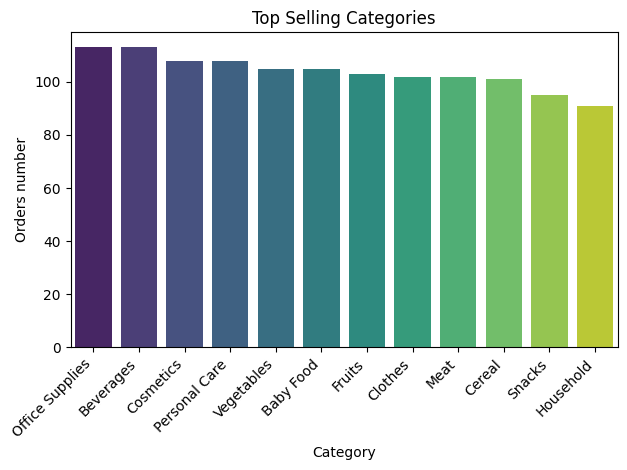

In [ ]:
sns.barplot(data=orders_number_by_category, y="count", x="item_type", palette="viridis", hue="item_type")
plt.title("Top Selling Categories")
plt.xlabel("Category")
plt.ylabel("Orders number")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()

plt.show()

In [ ]:
grouped_by_category = data.groupby("item_type")[["sales", "cogs", "profit"]].sum().reset_index()

grouped_by_category["sales_m"] = round(grouped_by_category["sales"] / 1000000, 2)
grouped_by_category["cogs_m"] = round(grouped_by_category["cogs"] / 1000000, 2)
grouped_by_category["profit_m"] = round(grouped_by_category["profit"] / 1000000, 2)
grouped_by_category = grouped_by_category.drop(columns=["sales", "cogs", "profit"])

grouped_by_category

,item_type,sales_m,cogs_m,profit_m
0,Baby Food,133.83,83.58,50.26
1,Beverages,27.43,18.37,9.05
2,Cereal,94.68,53.90,40.77
3,Clothes,63.31,20.76,42.54
4,Cosmetics,221.31,133.29,88.01
5,Fruits,4.96,3.68,1.28
6,Household,278.87,209.71,69.16
7,Meat,201.34,174.04,27.30
8,Office Supplies,378.67,305.25,73.41
9,Personal Care,43.35,30.06,13.29


In [ ]:
category_sorted_by_sales = grouped_by_category.sort_values(by="sales_m", ascending=False)
category_sorted_by_cogs = grouped_by_category.sort_values(by="cogs_m", ascending=False)
category_sorted_by_profit = grouped_by_category.sort_values(by="profit_m", ascending=False)

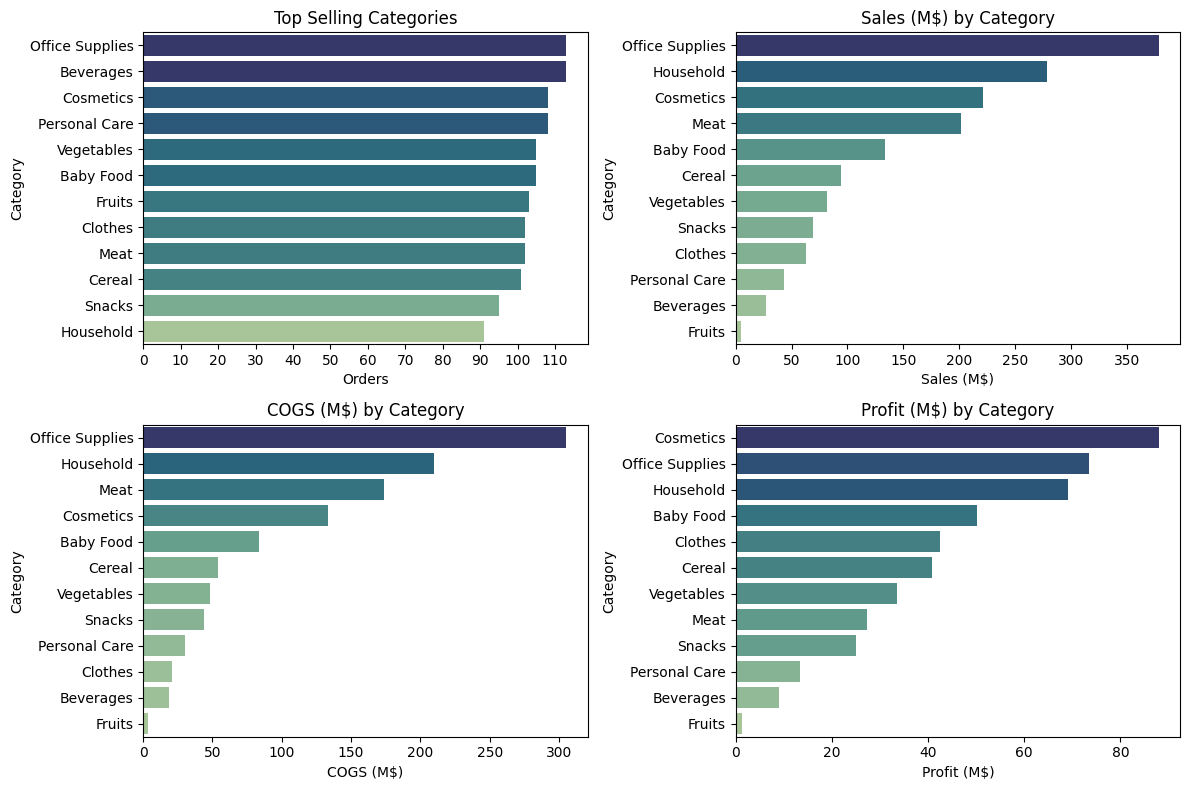

In [ ]:
fig, ax = plt.subplots(2, 2, figsize=(12, 8))

#popular categories
sns.barplot(data=orders_number_by_category, x="count", y="item_type", palette="crest", hue="count", ax=ax[0,0], legend=False)
ax[0,0].set_title("Top Selling Categories")
ax[0,0].set_xlabel("Orders")
ax[0,0].set_ylabel("Category")
x_ticks = np.arange(0, orders_number_by_category["count"].max() + 5, 10)
ax[0, 0].set_xticks(x_ticks)

#sales by category
sns.barplot(data=category_sorted_by_sales, x="sales_m", y="item_type", palette="crest", hue="sales_m", ax=ax[0,1], legend=False)
ax[0,1].set_title("Sales (M$) by Category")
ax[0,1].set_xlabel("Sales (M$)")
ax[0,1].set_ylabel("Category")

#cogs by category
sns.barplot(data=category_sorted_by_cogs, x="cogs_m", y="item_type", palette="crest", hue="cogs_m", ax=ax[1,0], legend=False)
ax[1,0].set_title("COGS (M$) by Category")
ax[1,0].set_xlabel("COGS (M$)")
ax[1,0].set_ylabel("Category")

#profit by category
sns.barplot(data=category_sorted_by_profit, x="profit_m", y="item_type", palette="crest", hue="profit_m", ax=ax[1,1], legend=False)
ax[1,1].set_title("Profit (M$) by Category")
ax[1,1].set_xlabel("Profit (M$)")
ax[1,1].set_ylabel("Category")

plt.tight_layout()
plt.show()

**Найчастіше** замовляють канцелярське приладдя, напої та косметику. **Найменш** часто - товари для дому.

При цьому *показники продажів напоїв* дуже низькі і поступаються за найменшим доходом, витратами і прибутком лише фруктам.

*Товари для дому* натомість займають 2 місце за вже згаданими показниками.
**Першість у продажах** (відповідно і витратах) належить **канцелярському приладдю**.

Проте **найбільше прибутку генерує косметика** за рахунок відносно низької собівартості.

##Аналіз продажів в ТОП-7 країнах за кількістю замовлень

In [ ]:
#продажі в розрізі географії (країн, регіонів)

data.head()

,order_id,order_date,ship_date,sales_channel,units_sold,unit_price,unit_cost,item_type,country,region,sub_region,sales,cogs,profit
0,100640618,2014-10-08,2014-10-18,Online,650.0,205.70,117.11,Cereal,Norway,Europe,Northern Europe,133705.00,76121.50,57583.50
1,100983083,2016-08-11,2016-08-11,Offline,1993.0,205.70,117.11,Cereal,Serbia,Europe,Southern Europe,409960.10,233400.23,176559.87
2,102230632,2017-05-13,2017-06-13,Online,1171.0,109.28,35.84,Clothes,Montenegro,Europe,Southern Europe,127966.88,41968.64,85998.24
3,103435266,2012-08-11,2012-09-18,Offline,7648.0,47.45,31.79,Beverages,Serbia,Europe,Southern Europe,362897.60,243129.92,119767.68
4,103450715,2015-03-15,2015-04-18,Online,2220.0,651.21,524.96,Office Supplies,Slovakia,Europe,Eastern Europe,1445686.20,1165411.20,280275.00


In [ ]:
top_countries_by_orders = data["country"].value_counts().nlargest(7).reset_index()
top_countries_by_orders

,country,count
0,San Marino,40
1,Andorra,40
2,Romania,34
3,Ukraine,33
4,Bosnia and Herzegovina,33
5,Russia,32
6,Malta,32


In [ ]:
grouped_by_country = data.groupby("country")[["sales", "cogs", "profit"]].sum().reset_index()

grouped_by_country["sales_m"] = round(grouped_by_country["sales"] / 1000000, 2)
grouped_by_country["cogs_m"] = round(grouped_by_country["cogs"] / 1000000, 2)
grouped_by_country["profit_m"] = round(grouped_by_country["profit"] / 1000000, 2)
grouped_by_country = grouped_by_country.drop(columns=["sales", "cogs", "profit"])

grouped_by_country.head()

,country,sales_m,cogs_m,profit_m
0,Albania,32.22,21.73,10.49
1,Andorra,47.76,32.35,15.41
2,Armenia,37.52,28.10,9.42
3,Austria,35.74,25.71,10.03
4,Belarus,34.24,22.38,11.85


In [ ]:
# сортування за кожною метрикою для побудови окремих графіків

top_countries_by_sales = grouped_by_country.sort_values(by="sales_m", ascending=False).nlargest(7, "sales_m")
top_countries_by_cogs = grouped_by_country.sort_values(by="cogs_m", ascending=False).nlargest(7, "cogs_m")
top_countries_by_profit = grouped_by_country.sort_values(by="profit_m", ascending=False).nlargest(7, "profit_m")

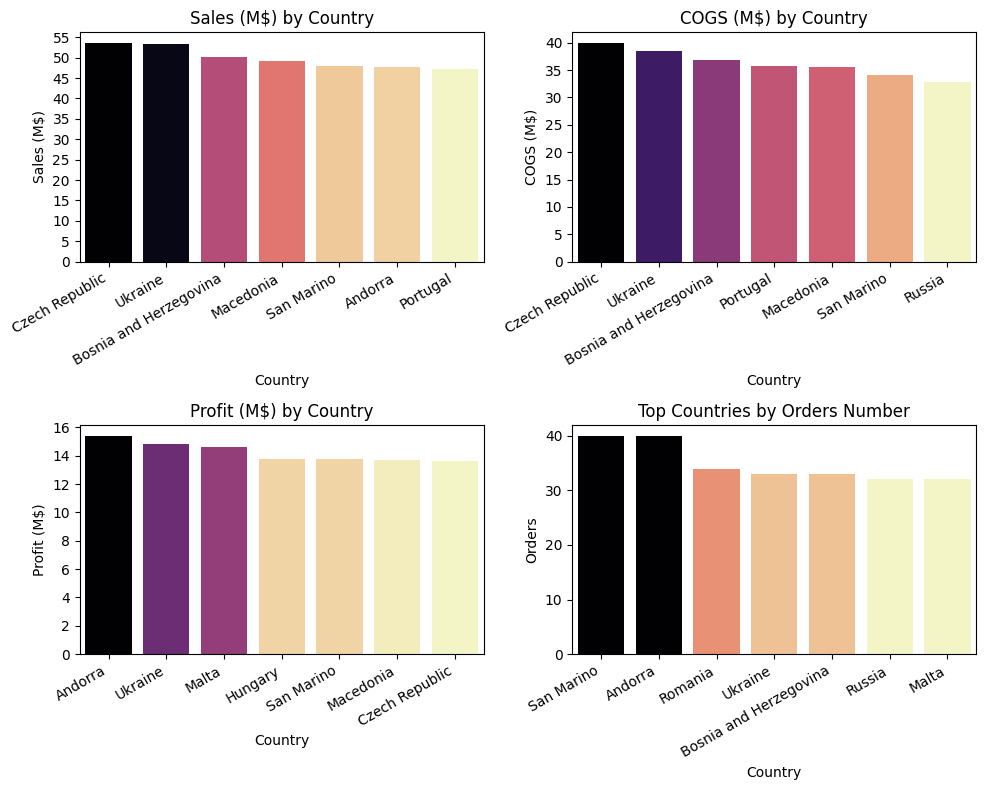

In [ ]:
fig, ax = plt.subplots(2, 2, figsize=(10, 8))

#orders by country
sns.barplot(data=top_countries_by_orders, y="count", x="country", palette="magma_r", hue="count", ax=ax[1,1], legend=False)
ax[1,1].set_title("Top Countries by Orders Number")
ax[1,1].set_xlabel("Country")
ax[1,1].set_ylabel("Orders")
ax[1,1].tick_params(axis="x", labelrotation=30)
plt.setp(ax[1,1].get_xticklabels(), ha="right")

#sales by country
sns.barplot(data=top_countries_by_sales, y="sales_m", x="country", palette="magma_r", hue="sales_m", ax=ax[0,0], legend=False)
ax[0,0].set_title("Sales (M$) by Country")
ax[0,0].set_ylabel("Sales (M$)")
ax[0,0].set_xlabel("Country")

ax[0,0].tick_params(axis="x", labelrotation=30)
plt.setp(ax[0,0].get_xticklabels(), ha="right")
ax[0,0].set_yticks(np.arange(0, ax[0,0].get_ylim()[1] + 2, 5))

#cogs by country
sns.barplot(data=top_countries_by_cogs, y="cogs_m", x="country", palette="magma_r", hue="cogs_m", ax=ax[0,1], legend=False)
ax[0,1].set_title("COGS (M$) by Country")
ax[0,1].set_ylabel("COGS (M$)")
ax[0,1].set_xlabel("Country")

ax[0,1].tick_params(axis="x", labelrotation=30)
plt.setp(ax[0,1].get_xticklabels(), ha="right")
ax[0,1].set_yticks(np.arange(0, ax[0,1].get_ylim()[1] + 2, 5))

#profit by country
sns.barplot(data=top_countries_by_profit, y="profit_m", x="country", palette="magma_r", hue="profit_m", ax=ax[1,0], legend=False)
ax[1,0].set_title("Profit (M$) by Country")
ax[1,0].set_ylabel("Profit (M$)")
ax[1,0].set_xlabel("Country")

ax[1,0].tick_params(axis="x", labelrotation=30)
plt.setp(ax[1,0].get_xticklabels(), ha="right")
ax[1,0].set_yticks(np.arange(0, ax[1,0].get_ylim()[1] + 1, 2))

plt.tight_layout()
plt.show()

Найвищий **дохід** (що тягне за собою найвищі витрати) приносить **Чехія**, проте найвищий **прибуток** генерує **Андорра**, натомість Чехія за прибутком посувається на 7 місце.

**Найчастіше** замовлення робили в **Сан-Марино та Андоррі**.

Україна, хоч і на 4 місці за кількістю замовлень, але займає 2 місце за всіма іншими показниками.

Скоріше за все, така різниця зумовлена специфікою різних категорій, що пропонує компанія (деякі товари мають нижчу/вищу відносну собівартість, товари деяких категорій замовляються у великій кількості тощо).

##Аналіз продажів у розрізі субрегіонів

In [ ]:
orders_number_by_region = data["sub_region"].value_counts().sort_values(ascending=False).reset_index()
orders_number_by_region

,sub_region,count
0,Southern Europe,411
1,Eastern Europe,271
2,Northern Europe,259
3,Western Europe,223
4,Western Asia,82


In [ ]:
grouped_by_region = data.groupby("sub_region")[["sales", "cogs", "profit"]].sum().reset_index()

grouped_by_region["sales_m"] = round(grouped_by_region["sales"] / 1000000, 2)
grouped_by_region["cogs_m"] = round(grouped_by_region["cogs"] / 1000000, 2)
grouped_by_region["profit_m"] = round(grouped_by_region["profit"] / 1000000, 2)
grouped_by_region = grouped_by_region.drop(columns=["sales", "cogs", "profit"])

grouped_by_region

,sub_region,sales_m,cogs_m,profit_m
0,Eastern Europe,378.69,267.41,111.27
1,Northern Europe,296.41,205.22,91.19
2,Southern Europe,562.03,395.74,166.30
3,Western Asia,93.33,68.18,25.15
4,Western Europe,268.52,188.73,79.79


In [ ]:
region_sorted_by_sales = grouped_by_region.sort_values(by="sales_m", ascending=False)
region_sorted_by_cogs = grouped_by_region.sort_values(by="cogs_m", ascending=False)
region_sorted_by_profit = grouped_by_region.sort_values(by="profit_m", ascending=False)

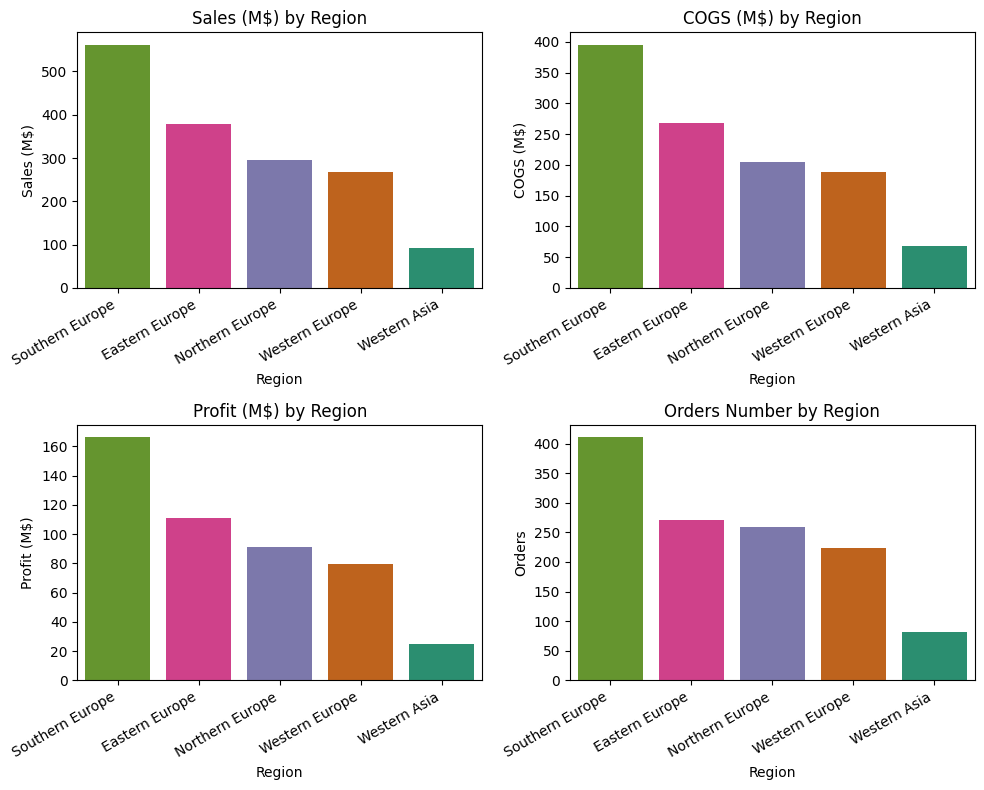

In [ ]:
fig, ax = plt.subplots(2, 2, figsize=(10, 8))

#orders by country
sns.barplot(data=orders_number_by_region, y="count", x="sub_region", palette="Dark2", hue="count", ax=ax[1,1], legend=False)
ax[1,1].set_title("Orders Number by Region")
ax[1,1].set_xlabel("Region")
ax[1,1].set_ylabel("Orders")

ax[1,1].tick_params(axis="x", labelrotation=30)
plt.setp(ax[1,1].get_xticklabels(), ha="right")

#sales by country
sns.barplot(data=region_sorted_by_sales, y="sales_m", x="sub_region", palette="Dark2", hue="sales_m", ax=ax[0,0], legend=False)
ax[0,0].set_title("Sales (M$) by Region")
ax[0,0].set_ylabel("Sales (M$)")
ax[0,0].set_xlabel("Region")

ax[0,0].tick_params(axis="x", labelrotation=30)
plt.setp(ax[0,0].get_xticklabels(), ha="right")

#cogs by country
sns.barplot(data=region_sorted_by_cogs, y="cogs_m", x="sub_region", palette="Dark2", hue="cogs_m", ax=ax[0,1], legend=False)
ax[0,1].set_title("COGS (M$) by Region")
ax[0,1].set_ylabel("COGS (M$)")
ax[0,1].set_xlabel("Region")

ax[0,1].tick_params(axis="x", labelrotation=30)
plt.setp(ax[0,1].get_xticklabels(), ha="right")

#profit by country
sns.barplot(data=region_sorted_by_profit, y="profit_m", x="sub_region", palette="Dark2", hue="profit_m", ax=ax[1,0], legend=False)
ax[1,0].set_title("Profit (M$) by Region")
ax[1,0].set_ylabel("Profit (M$)")
ax[1,0].set_xlabel("Region")

ax[1,0].tick_params(axis="x", labelrotation=30)
plt.setp(ax[1,0].get_xticklabels(), ha="right")

plt.tight_layout()
plt.show()

**Найвищі** показники замовлень, доходу, витрат і прибутку -  у **Південній Європі**. Щодо Європи як регіону в цілому - найменше замовлень саме в Західній.

Найнижчими показниками характеризується Азія, при цьому купівельна активність відбувалася лише в Західній Азії.

In [ ]:
data.head()

,order_id,order_date,ship_date,sales_channel,units_sold,unit_price,unit_cost,item_type,country,region,sub_region,sales,cogs,profit
0,100640618,2014-10-08,2014-10-18,Online,650.0,205.70,117.11,Cereal,Norway,Europe,Northern Europe,133705.00,76121.50,57583.50
1,100983083,2016-08-11,2016-08-11,Offline,1993.0,205.70,117.11,Cereal,Serbia,Europe,Southern Europe,409960.10,233400.23,176559.87
2,102230632,2017-05-13,2017-06-13,Online,1171.0,109.28,35.84,Clothes,Montenegro,Europe,Southern Europe,127966.88,41968.64,85998.24
3,103435266,2012-08-11,2012-09-18,Offline,7648.0,47.45,31.79,Beverages,Serbia,Europe,Southern Europe,362897.60,243129.92,119767.68
4,103450715,2015-03-15,2015-04-18,Online,2220.0,651.21,524.96,Office Supplies,Slovakia,Europe,Eastern Europe,1445686.20,1165411.20,280275.00


##Аналіз продажів за каналами продажу

In [ ]:
# аналіз продажів в розрізі каналів продажу

channel_counts = data["sales_channel"].value_counts().sort_values().reset_index()
channel_counts

,sales_channel,count
0,Offline,621
1,Online,625


In [ ]:
grouped_by_channel = data.groupby(["sales_channel"])[["sales", "cogs", "profit"]].sum().reset_index()

grouped_by_channel["sales_m"] = round(grouped_by_channel["sales"] / 1000000, 2)
grouped_by_channel["cogs_m"] = round(grouped_by_channel["cogs"] / 1000000, 2)
grouped_by_channel["profit_m"] = round(grouped_by_channel["profit"] / 1000000, 2)
grouped_by_channel = grouped_by_channel.drop(columns=["sales", "cogs", "profit"])

grouped_by_channel

,sales_channel,sales_m,cogs_m,profit_m
0,Offline,810.03,571.52,238.51
1,Online,788.95,553.76,235.20


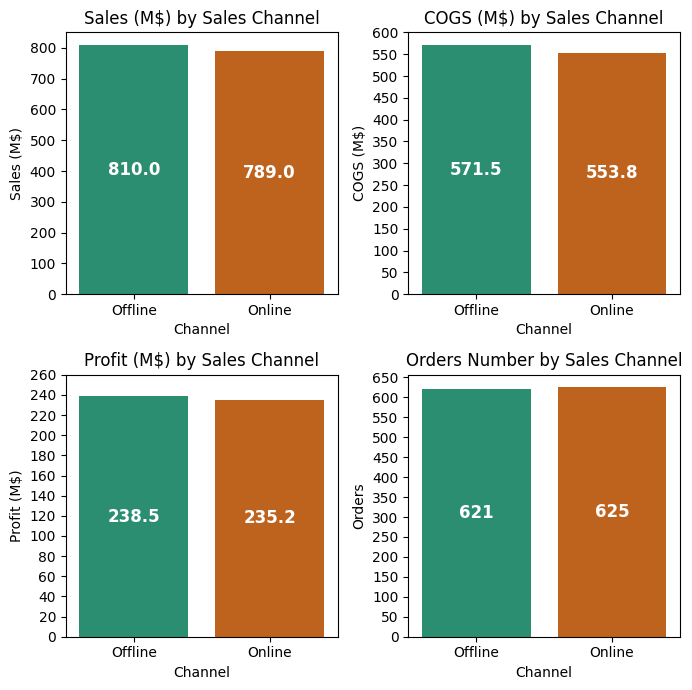

In [ ]:
fig, ax = plt.subplots(2, 2, figsize=(7, 7))

#orders by country
sns.barplot(data=channel_counts, y="count", x="sales_channel", palette="Dark2", hue="sales_channel", ax=ax[1,1])
ax[1,1].set_title("Orders Number by Sales Channel")
ax[1,1].set_xlabel("Channel")
ax[1,1].set_ylabel("Orders")

ax[1,1].set_yticks(np.arange(0, ax[1,1].get_ylim()[1] + 20, 50))

for x, value in zip(ax[1,1].get_xticks(), channel_counts["count"]):
    ax[1,1].text(x, value / 2, f"{int(value)}", ha="center", va="center", color="white", fontsize=12, fontweight="bold")

#sales by country
sns.barplot(data=grouped_by_channel, y="sales_m", x="sales_channel", palette="Dark2", hue="sales_channel", ax=ax[0,0])
ax[0,0].set_title("Sales (M$) by Sales Channel")
ax[0,0].set_ylabel("Sales (M$)")
ax[0,0].set_xlabel("Channel")

ax[0,0].set_yticks(np.arange(0, ax[0,0].get_ylim()[1] + 20, 100))

for x, value in zip(ax[0,0].get_xticks(), grouped_by_channel["sales_m"]):
    ax[0,0].text(x, value / 2, f"{value:.1f}", ha="center", va="center", color="white", fontsize=12, fontweight="bold")

#cogs by country
sns.barplot(data=grouped_by_channel, y="cogs_m", x="sales_channel", palette="Dark2", hue="sales_channel", ax=ax[0,1])
ax[0,1].set_title("COGS (M$) by Sales Channel")
ax[0,1].set_ylabel("COGS (M$)")
ax[0,1].set_xlabel("Channel")

ax[0,1].set_yticks(np.arange(0, ax[0,1].get_ylim()[1] + 20, 50))

for x, value in zip(ax[0,1].get_xticks(), grouped_by_channel["cogs_m"]):
    ax[0,1].text(x, value / 2, f"{value:.1f}", ha="center", va="center", color="white", fontsize=12, fontweight="bold")

#profit by country
sns.barplot(data=grouped_by_channel, y="profit_m", x="sales_channel", palette="Dark2", hue="sales_channel", ax=ax[1,0])
ax[1,0].set_title("Profit (M$) by Sales Channel")
ax[1,0].set_ylabel("Profit (M$)")
ax[1,0].set_xlabel("Channel")

ax[1,0].set_yticks(np.arange(0, ax[1,0].get_ylim()[1] + 20, 20))

for x, value in zip(ax[1,0].get_xticks(), grouped_by_channel["profit_m"]):
    ax[1,0].text(x, value / 2, f"{value:.1f}", ha="center", va="center", color="white", fontsize=12, fontweight="bold")

plt.tight_layout()
plt.show()


Замовлень онлайн відбувається дещо більше, ніж офлайн (на 4), проте в загальному масштабі це дуже мала різниця. Тож можемо стверджувати, що обидва канали продажу використовуються майже однаково.

Слід зазначити, що **значно більше доходів** генерують саме **офлайн-продажі**. Вони також випереджають онлайн-продажі в прибутку (хоч і значно меншою мірою, адже витрати його "з'їдають").

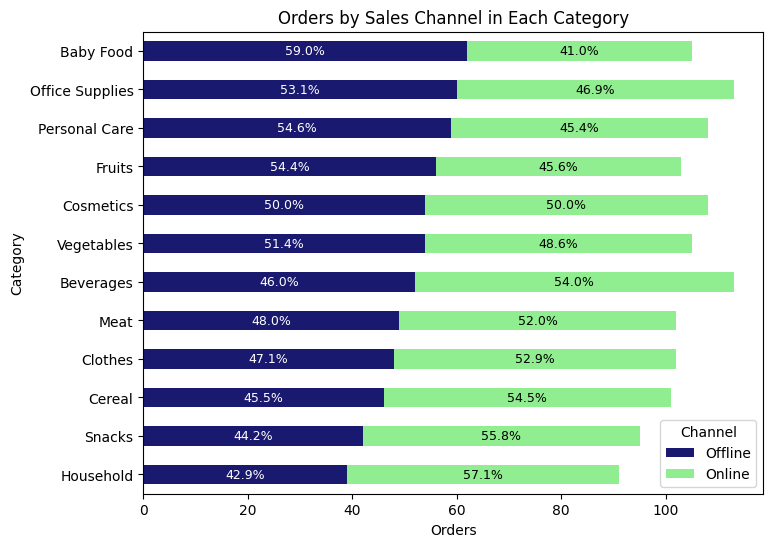

In [ ]:
#Аналіз в розрізі каналів і категорій

category_channel_counts = data.groupby(["item_type", "sales_channel"])["order_id"].count().unstack().sort_values(by="Offline")

colors = ["midnightblue", "lightgreen"]

fig, ax = plt.subplots(figsize=(8, 6))
category_channel_counts.plot(kind="barh", stacked=True, ax=ax, color=colors)

share_offline = (category_channel_counts["Offline"] / category_channel_counts.sum(axis=1) * 100).round(1)
share_online = (category_channel_counts["Online"] / category_channel_counts.sum(axis=1) * 100).round(1)

for i, category in enumerate(category_channel_counts.index):
    offline = category_channel_counts.loc[category, "Offline"]
    online = category_channel_counts.loc[category, "Online"]

# Offline %
    ax.text(offline / 2, i, f"{share_offline[category]}%", va="center", ha="center", color="white", fontsize=9)
# Online %
    ax.text(offline + online / 2, i, f"{share_online[category]}%", va="center", ha="center", color="black", fontsize=9)


plt.title("Orders by Sales Channel in Each Category")
plt.xlabel("Orders")
plt.ylabel("Category")
plt.legend(title="Channel")
plt.show()


Графік демонструє: такі товари, як дитяче харчування, канцелярське приладдя, догляд за собою та фрукти споживачі частіше купують **офлайн**.

Тоді як їжу та напої, одяг і товари для дому вони частіше замовляють **онлайн**.

#Аналіз інтервалу часу між замовленням та його відвантаженням

In [ ]:
# аналіз інтервалу часу між замовленням та його відвантаженням

data["days_diff"] = (data["ship_date"] - data["order_date"]).dt.days
data.head()

,order_id,order_date,ship_date,sales_channel,units_sold,unit_price,unit_cost,item_type,country,region,sub_region,sales,cogs,profit,days_diff
0,100640618,2014-10-08,2014-10-18,Online,650.0,205.70,117.11,Cereal,Norway,Europe,Northern Europe,133705.00,76121.50,57583.50,10
1,100983083,2016-08-11,2016-08-11,Offline,1993.0,205.70,117.11,Cereal,Serbia,Europe,Southern Europe,409960.10,233400.23,176559.87,0
2,102230632,2017-05-13,2017-06-13,Online,1171.0,109.28,35.84,Clothes,Montenegro,Europe,Southern Europe,127966.88,41968.64,85998.24,31
3,103435266,2012-08-11,2012-09-18,Offline,7648.0,47.45,31.79,Beverages,Serbia,Europe,Southern Europe,362897.60,243129.92,119767.68,38
4,103450715,2015-03-15,2015-04-18,Online,2220.0,651.21,524.96,Office Supplies,Slovakia,Europe,Eastern Europe,1445686.20,1165411.20,280275.00,34


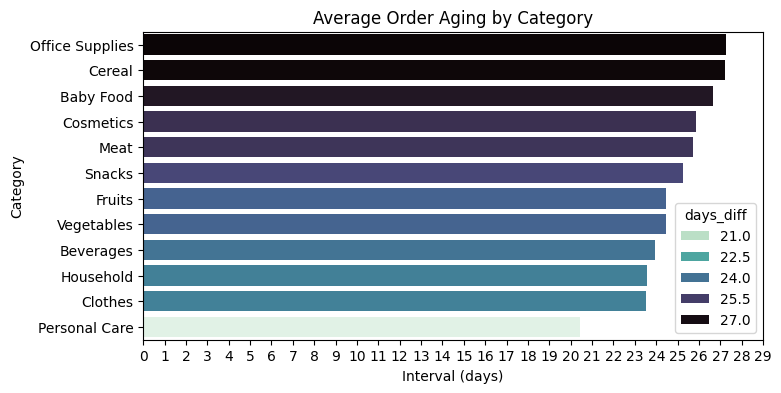

In [ ]:
# аналіз інтервалу часу між замовленням та його відвантаженням у розрізі категорій товару

time_diff_categories_grouped = data.groupby("item_type")["days_diff"].mean().sort_values(ascending=False).reset_index()

plt.figure(figsize=(8, 4))
sns.barplot(data = time_diff_categories_grouped, y = "item_type", x = "days_diff", palette="mako_r", hue="days_diff")
plt.title("Average Order Aging by Category")
plt.xlabel("Interval (days)")
plt.ylabel("Category")
plt.xticks(np.arange(0, time_diff_categories_grouped["days_diff"].max() + 2, 1))
plt.show()

Отже, інтервал часу між замовленням та його відвантаженням **найбільший** для таких категорій, як канцелярське приладдя, крупи, дитяче харчування, косметика та м'ясо.

**Найшвидше** відправляється замовлення товарів для дому, одягу та догляду за собою.

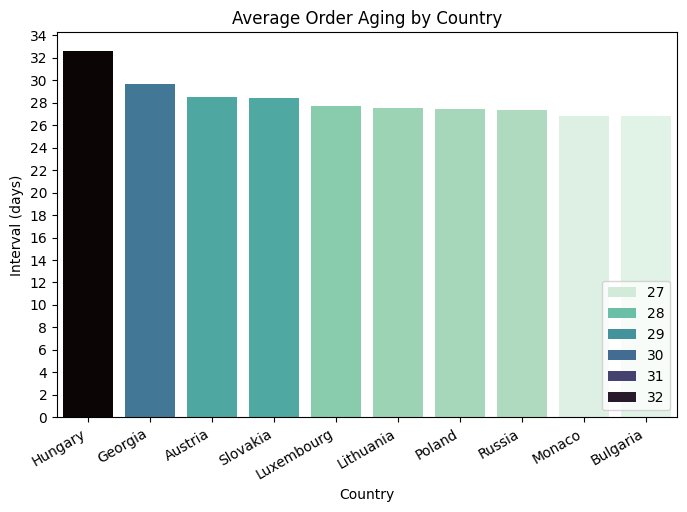

In [ ]:
# аналіз інтервалу часу між замовленням та його відвантаженням у розрізі країн

time_diff_country_grouped = data.groupby("country")["days_diff"].mean().sort_values(ascending=False).nlargest(10).reset_index()

plt.figure(figsize=(8, 5))
sns.barplot(data = time_diff_country_grouped, x = "country", y = "days_diff", palette="mako_r", hue="days_diff")
plt.title("Average Order Aging by Country")
plt.ylabel("Interval (days)")
plt.xlabel("Country")
plt.yticks(np.arange(0, time_diff_country_grouped["days_diff"].max() + 2, 2))
plt.xticks(rotation=30, ha="right")
plt.legend(loc="lower right")

plt.show()

Отже, найбільший інтервал між замовленням і відвантаженням - в Угорщині, Грузії, Австрії та Словаччині.

Компанії слід пересвідчитися, чи існують в цих країнах проблеми з логістикою.

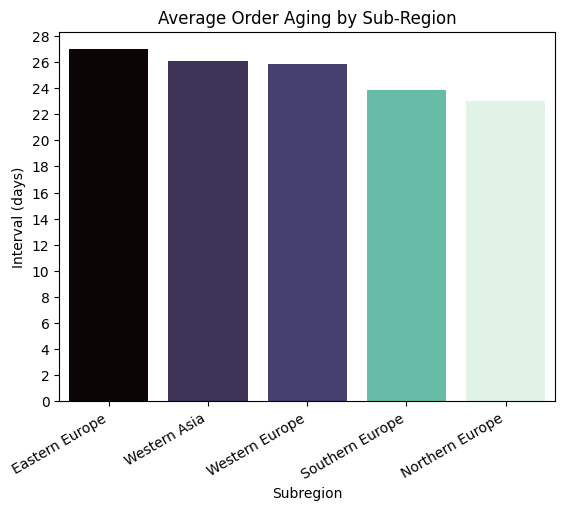

In [ ]:
# аналіз інтервалу часу між замовленням та його відвантаженням у розрізі субрегіонів

time_diff_subregion_grouped = data.groupby("sub_region")["days_diff"].mean().sort_values(ascending=False).reset_index()

sns.barplot(data = time_diff_subregion_grouped, x = "sub_region", y = "days_diff", palette="mako_r", hue="days_diff", legend=False)
plt.title("Average Order Aging by Sub-Region")
plt.ylabel("Interval (days)")
plt.xlabel("Subregion")
plt.yticks(np.arange(0, time_diff_subregion_grouped["days_diff"].max() + 2, 2))
plt.xticks(rotation=30, ha="right")

plt.show()

Усі субрегіони характеризуються **відносно високими середніми значеннями**. Найбільші - в Східній Європі та Західній Азії.

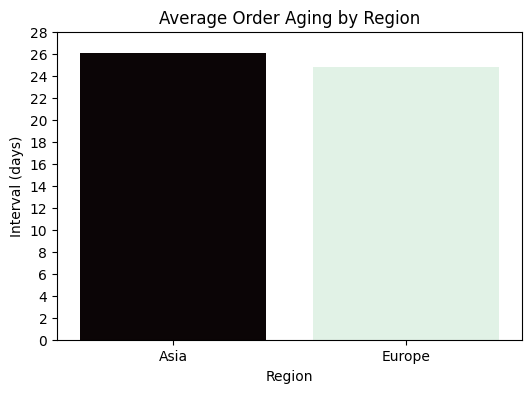

In [ ]:
# аналіз інтервалу часу між замовленням та його відвантаженням у розрізі регіонів

time_diff_region_grouped = data.groupby("region")["days_diff"].mean().sort_values(ascending=False).reset_index()

plt.figure(figsize=(6, 4))

sns.barplot(data = time_diff_region_grouped, x = "region", y = "days_diff", palette="mako_r", hue="days_diff", legend=False)
plt.title("Average Order Aging by Region")
plt.ylabel("Interval (days)")
plt.xlabel("Region")
plt.yticks(np.arange(0, time_diff_region_grouped["days_diff"].max() + 2, 2))

plt.show()

Обидва регіони характеризуються великими середніми інтервалами між створенням і відвантаженням замовлення (25-26).

#Залежність прибутку від часу, необхідного на відвантаження товару

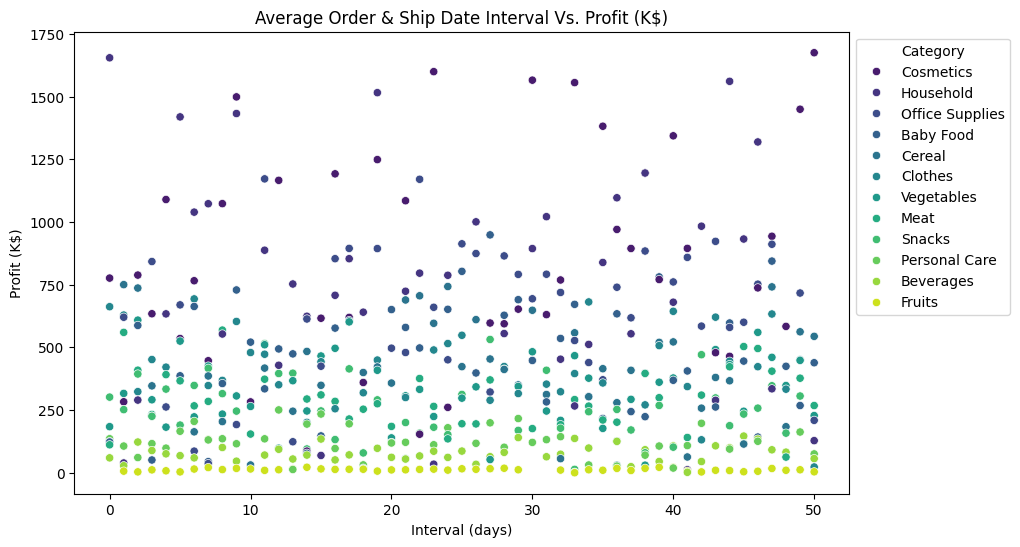

In [ ]:
# чи залежить прибуток від часу, необхідного на відвантаження товару?

plt.figure(figsize=(10, 6))

interval_profit_grouped = data.groupby(["days_diff", "item_type"])["profit"].mean().sort_values(ascending=False).reset_index()
interval_profit_grouped["profit_k"] = interval_profit_grouped["profit"] / 1000

sns.scatterplot(data=interval_profit_grouped, x="days_diff", y="profit_k", hue="item_type", palette="viridis")
plt.title("Average Order & Ship Date Interval Vs. Profit (K$)")
plt.xlabel("Interval (days)")
plt.ylabel("Profit (K$)")
plt.legend(title="Category", bbox_to_anchor=(1, 1), loc="upper left")
plt.show()

Прибуток **не залежить** від часу, необхідного на відвантаження товару.

# Аналіз динаміки продажів з 2015 року

##Динаміка продажів у розрізі категорій товарів

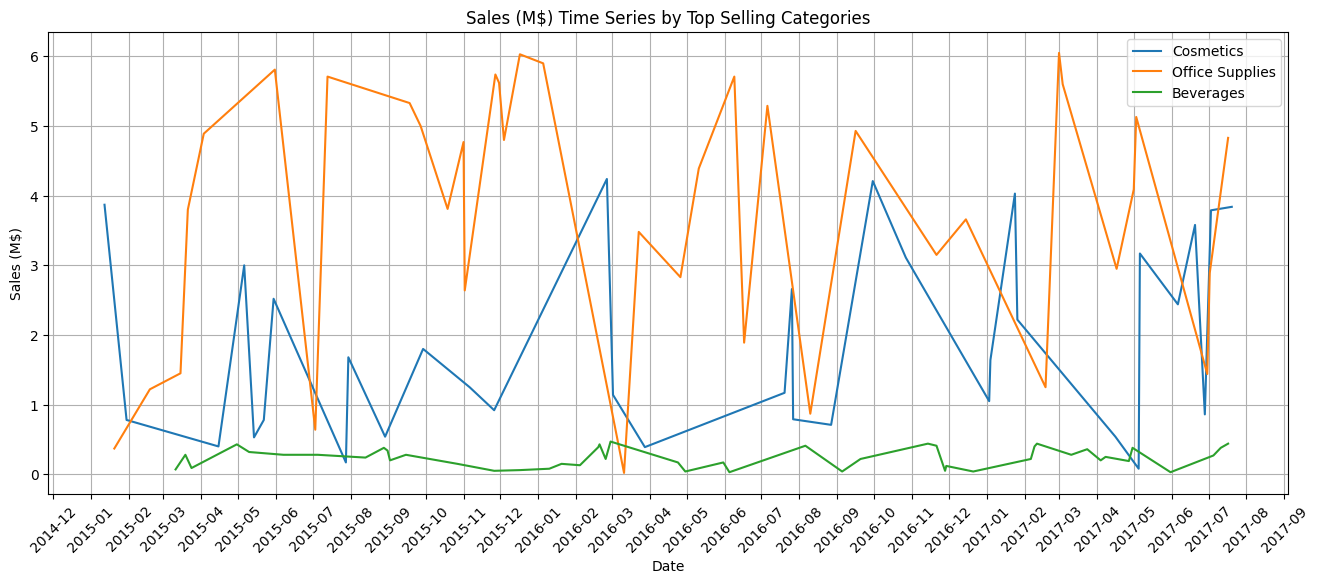

In [ ]:
# динаміка продажів у розрізі категорій товарів

data_2015 = data[data["order_date"] >= "2015-01-01"]
top_3_categories = (data.groupby("item_type")["order_id"].nunique().sort_values(ascending=False).head(3).index)
data_top3 = data_2015[data_2015["item_type"].isin(top_3_categories)]

sales_by_categories_time_grouped = data_top3.groupby(["item_type", "order_date"])[["sales"]].sum().sort_values(by="order_date").reset_index()

sales_by_categories_time_grouped["sales_m"] = round(sales_by_categories_time_grouped["sales"] / 1000000, 2)
sales_by_categories_time_grouped = sales_by_categories_time_grouped.drop(columns=["sales"])

categories1 = sales_by_categories_time_grouped["item_type"].unique()

plt.figure(figsize=(16, 6))
for category in categories1:
    category_data_1 = sales_by_categories_time_grouped[sales_by_categories_time_grouped["item_type"] == category]
    plt.plot(category_data_1["order_date"], category_data_1["sales_m"], label=category)

ax = plt.gca()
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=1))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
plt.xticks(rotation=45)

plt.xlabel("Date")
plt.ylabel("Sales (M$)")
plt.title("Sales (M$) Time Series by Top Selling Categories")
plt.legend()
plt.grid(True)
plt.show()

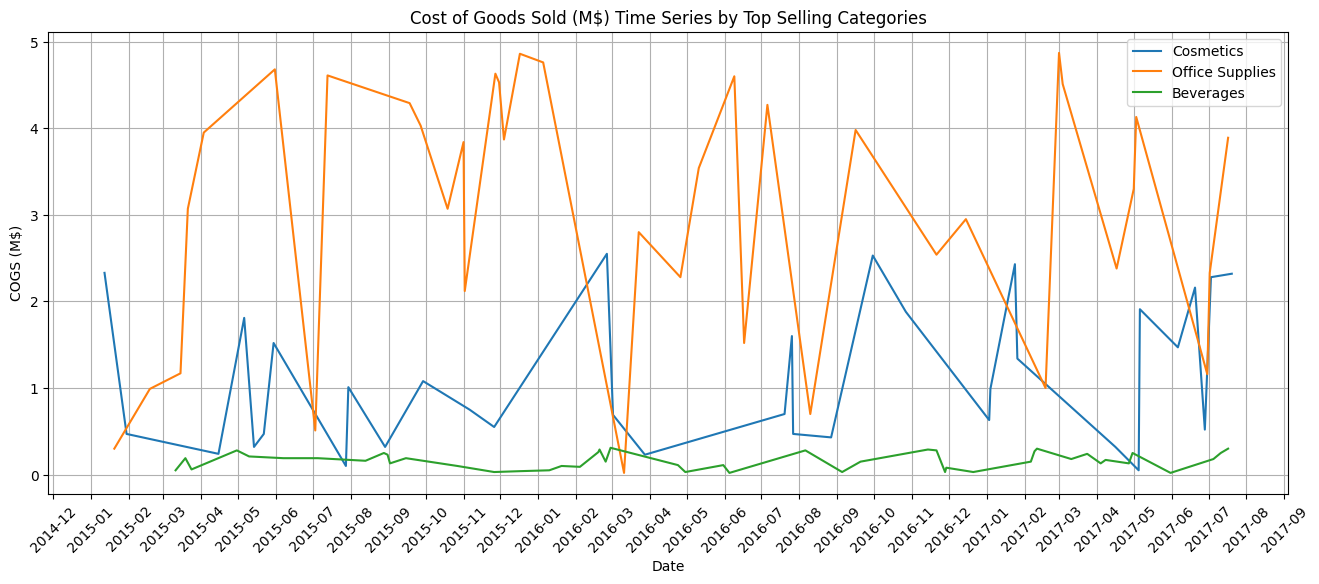

In [ ]:
cogs_by_categories_time_grouped = data_top3.groupby(["item_type", "order_date"])[["cogs"]].sum().sort_values(by="order_date").reset_index()

cogs_by_categories_time_grouped["cogs_m"] = round(cogs_by_categories_time_grouped["cogs"] / 1000000, 2)
cogs_by_categories_time_grouped = cogs_by_categories_time_grouped.drop(columns=["cogs"])

categories2 = cogs_by_categories_time_grouped["item_type"].unique()

plt.figure(figsize=(16, 6))
for category in categories2:
    category_data_2 = cogs_by_categories_time_grouped[cogs_by_categories_time_grouped["item_type"] == category]
    plt.plot(category_data_2["order_date"], category_data_2["cogs_m"], label=category)

ax = plt.gca()
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=1))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
plt.xticks(rotation=45)

plt.xlabel("Date")
plt.ylabel("COGS (M$)")
plt.title("Cost of Goods Sold (M$) Time Series by Top Selling Categories")
plt.legend()
plt.grid(True)
plt.show()

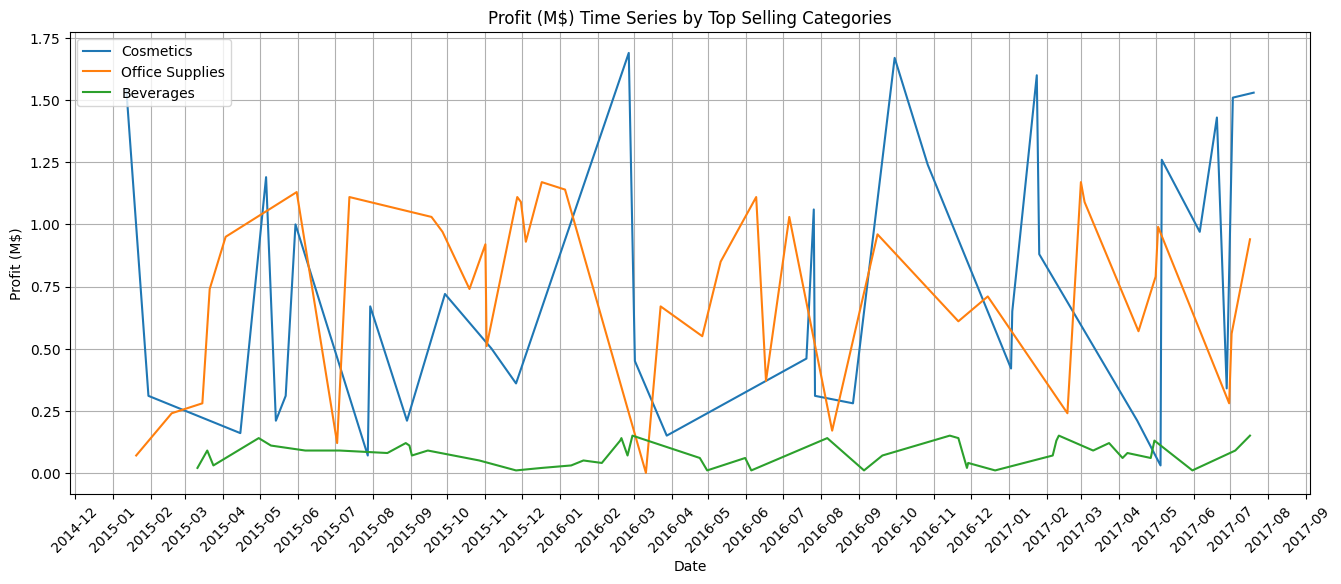

In [ ]:
profit_by_categories_time_grouped = data_top3.groupby(["item_type", "order_date"])[["profit"]].sum().sort_values(by="order_date").reset_index()

profit_by_categories_time_grouped["profit_m"] = round(profit_by_categories_time_grouped["profit"] / 1000000, 2)
profit_by_categories_time_grouped = profit_by_categories_time_grouped.drop(columns=["profit"])

categories3 = profit_by_categories_time_grouped["item_type"].unique()

plt.figure(figsize=(16, 6))
for category in categories3:
    category_data_3 = profit_by_categories_time_grouped[profit_by_categories_time_grouped["item_type"] == category]
    plt.plot(category_data_3["order_date"], category_data_3["profit_m"], label=category)

ax = plt.gca()
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=1))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
plt.xticks(rotation=45)

plt.xlabel("Date")
plt.ylabel("Profit (M$)")
plt.title("Profit (M$) Time Series by Top Selling Categories")
plt.legend()
plt.grid(True)
plt.show()

Динаміка продажів найбільш популярних категорій демонструє періодичні злети та падіння показників (патерни виручки, витрат і прибутку при цьому однакові), однак *чітко виражена тенденція не спостерігається*.

Значний розмах може пояснюватися різними чинниками (напркилад, акції та заходи з боку компанії) та потребує більш детального вивчення контексту.

##Динаміка продажів у розрізі країн

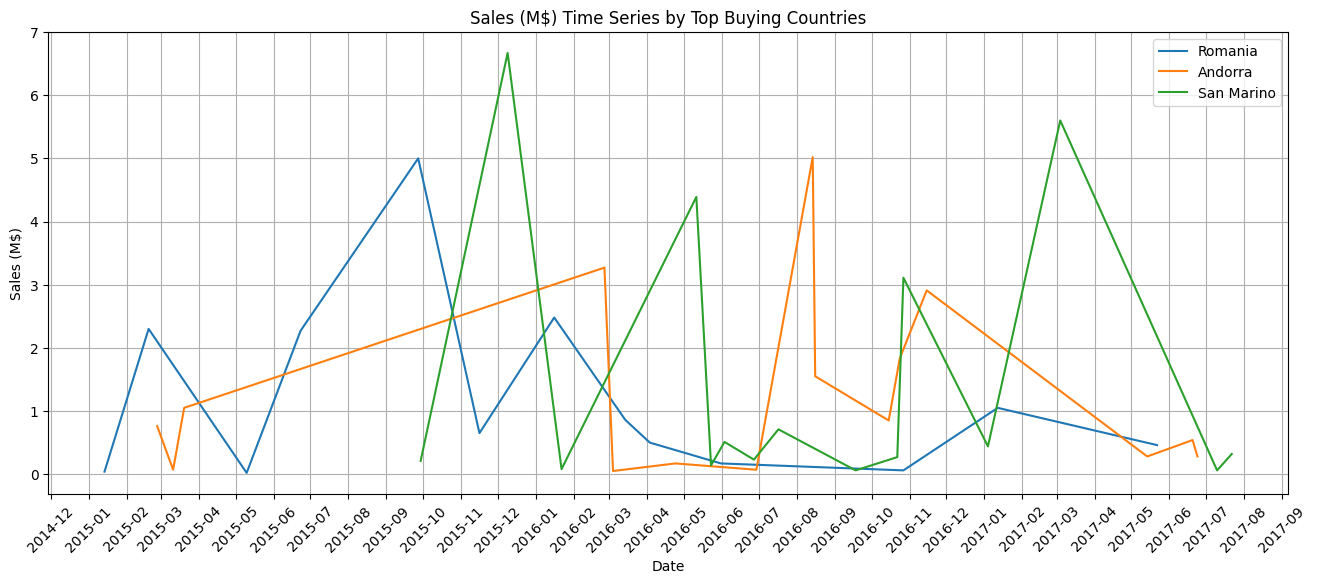

In [ ]:
# динаміка продажів у розрізі країн

data_2015 = data[data["order_date"] >= "2015-01-01"]
top_3_countries = (data.groupby("country")["order_id"].nunique().sort_values(ascending=False).head(3).index)
data_top3 = data_2015[data_2015["country"].isin(top_3_countries)]

sales_by_countries_time_grouped = data_top3.groupby(["country", "order_date"])[["sales"]].sum().sort_values(by="order_date").reset_index()

sales_by_countries_time_grouped["sales_m"] = round(sales_by_countries_time_grouped["sales"] / 1000000, 2)
sales_by_countries_time_grouped = sales_by_countries_time_grouped.drop(columns=["sales"])

countries1 = sales_by_countries_time_grouped["country"].unique()

plt.figure(figsize=(16, 6))
for country in countries1:
    country_data_1 = sales_by_countries_time_grouped[sales_by_countries_time_grouped["country"] == country]
    plt.plot(country_data_1["order_date"], country_data_1["sales_m"], label=country)

ax = plt.gca()
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=1))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
plt.xticks(rotation=45)

plt.xlabel("Date")
plt.ylabel("Sales (M$)")
plt.title("Sales (M$) Time Series by Top Buying Countries")
plt.legend()
plt.grid(True)
plt.show()

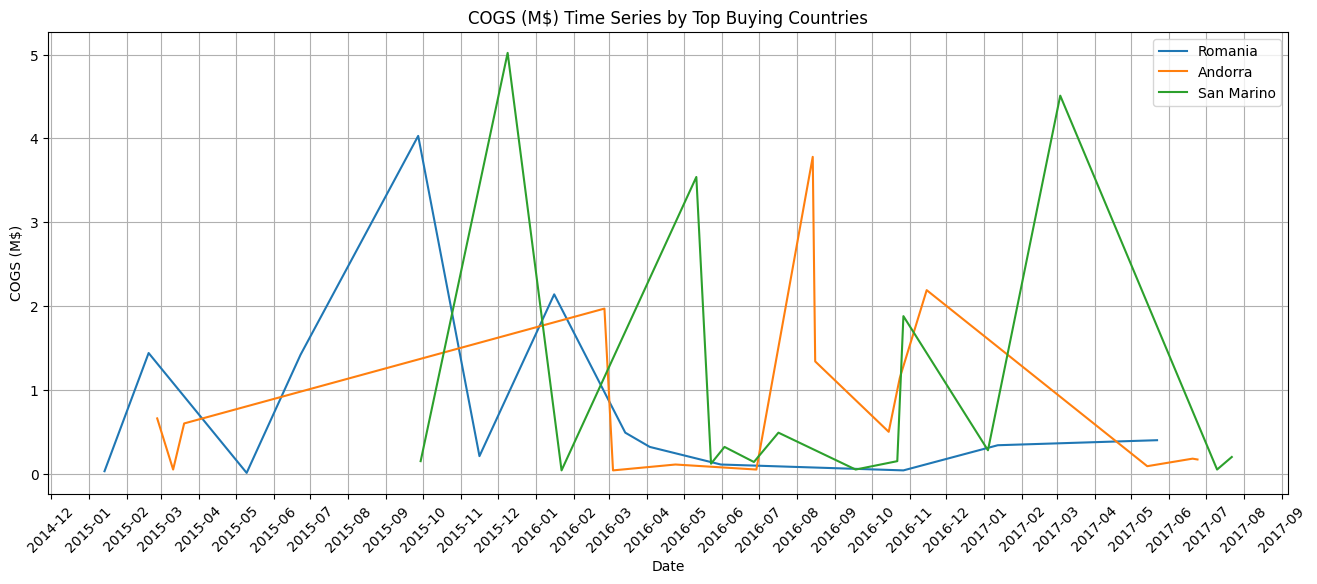

In [ ]:
cogs_by_countries_time_grouped = data_top3.groupby(["country", "order_date"])[["cogs"]].sum().sort_values(by="order_date").reset_index()

cogs_by_countries_time_grouped["cogs_m"] = round(cogs_by_countries_time_grouped["cogs"] / 1000000, 2)
cogs_by_countries_time_grouped = cogs_by_countries_time_grouped.drop(columns=["cogs"])

countries2 = cogs_by_countries_time_grouped["country"].unique()

plt.figure(figsize=(16, 6))
for country in countries2:
    country_data_2 = cogs_by_countries_time_grouped[cogs_by_countries_time_grouped["country"] == country]
    plt.plot(country_data_2["order_date"], country_data_2["cogs_m"], label=country)

ax = plt.gca()
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=1))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
plt.xticks(rotation=45)

plt.xlabel("Date")
plt.ylabel("COGS (M$)")
plt.title("COGS (M$) Time Series by Top Buying Countries")
plt.legend()
plt.grid(True)
plt.show()

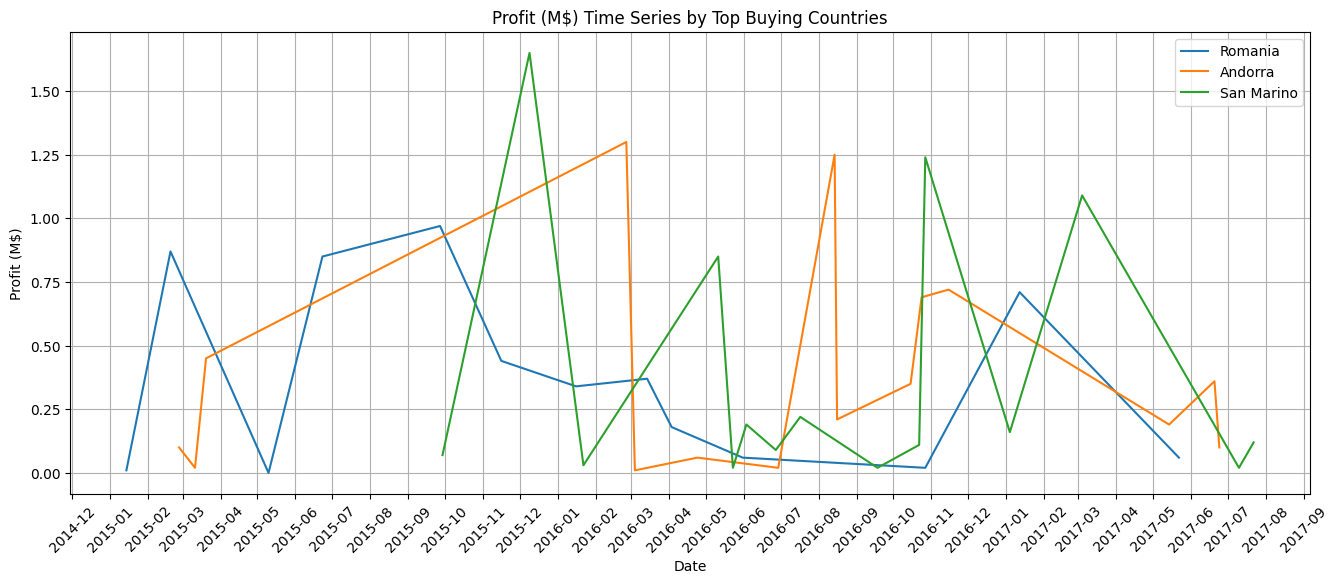

In [ ]:
profit_by_countries_time_grouped = data_top3.groupby(["country", "order_date"])[["profit"]].sum().sort_values(by="order_date").reset_index()

profit_by_countries_time_grouped["profit_m"] = round(profit_by_countries_time_grouped["profit"] / 1000000, 2)
profit_by_countries_time_grouped = profit_by_countries_time_grouped.drop(columns=["profit"])

countries3 = profit_by_countries_time_grouped["country"].unique()

plt.figure(figsize=(16, 6))
for country in countries3:
    country_data_3 = profit_by_countries_time_grouped[profit_by_countries_time_grouped["country"] == country]
    plt.plot(country_data_3["order_date"], country_data_3["profit_m"], label=country)

ax = plt.gca()
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=1))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
plt.xticks(rotation=45)

plt.xlabel("Date")
plt.ylabel("Profit (M$)")
plt.title("Profit (M$) Time Series by Top Buying Countries")
plt.legend()
plt.grid(True)
plt.show()

Динаміка продажів у країнах із найбільшою кількістю замовлень демонструє періодичні злети та падіння показників (патерни виручки, витрат і прибутку при цьому однакові), однак *чітко виражена тенденція не спостерігається*.

Слід, однак, зазначити, що в **липні 2016 року** **прибуток** у всіх трьох категоріях **впав** до одних із найнижчих показників, що навряд було випадковістю.

Такі різкі коливання потребують більш детального вивчення контексту.

##Динаміка продажів у розрізі регіонів

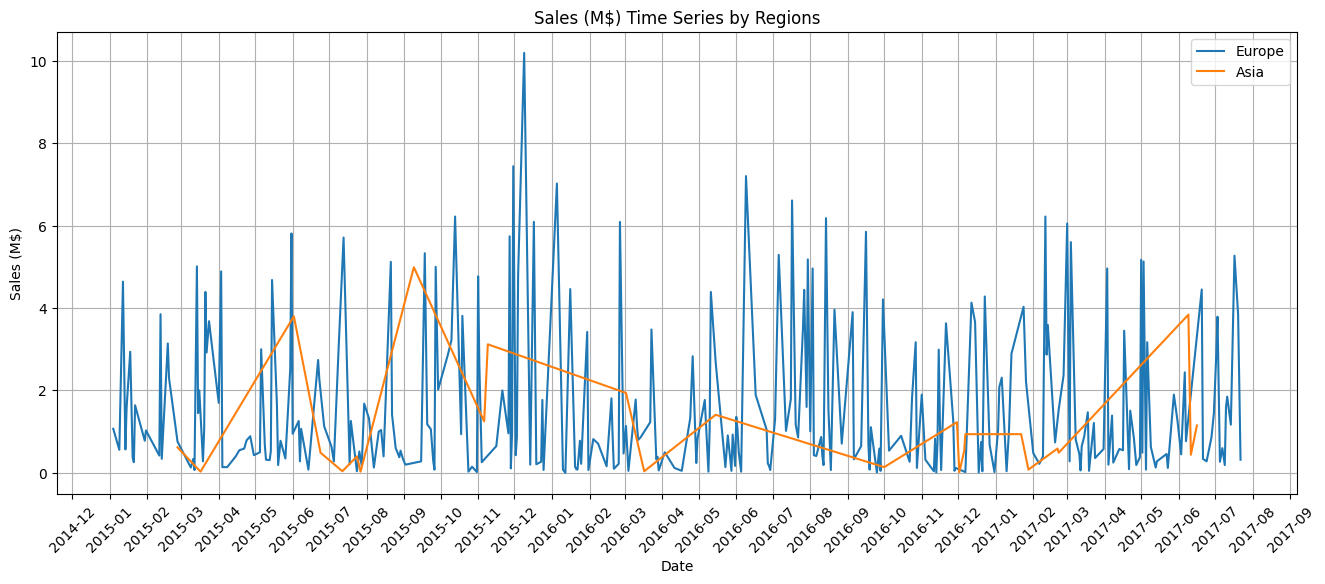

In [ ]:
# динаміка продажів у розрізі регіонів

data_2015 = data[data["order_date"] >= "2015-01-01"]

sales_by_regions_time_grouped = (data_2015.groupby(["region", "order_date"])[["sales"]].sum().sort_values(by="order_date").reset_index())

sales_by_regions_time_grouped["sales_m"] = round(sales_by_regions_time_grouped["sales"] / 1_000_000, 2)

sales_by_regions_time_grouped = sales_by_regions_time_grouped.drop(columns=["sales"])

regions1 = sales_by_regions_time_grouped["region"].unique()

plt.figure(figsize=(16, 6))
for region in regions1:
    region_data_1 = sales_by_regions_time_grouped[sales_by_regions_time_grouped["region"] == region]
    plt.plot(region_data_1["order_date"], region_data_1["sales_m"], label=region
    )

ax = plt.gca()
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=1))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
plt.xticks(rotation=45)

plt.xlabel("Date")
plt.ylabel("Sales (M$)")
plt.title("Sales (M$) Time Series by Regions")
plt.legend()
plt.grid(True)
plt.show()

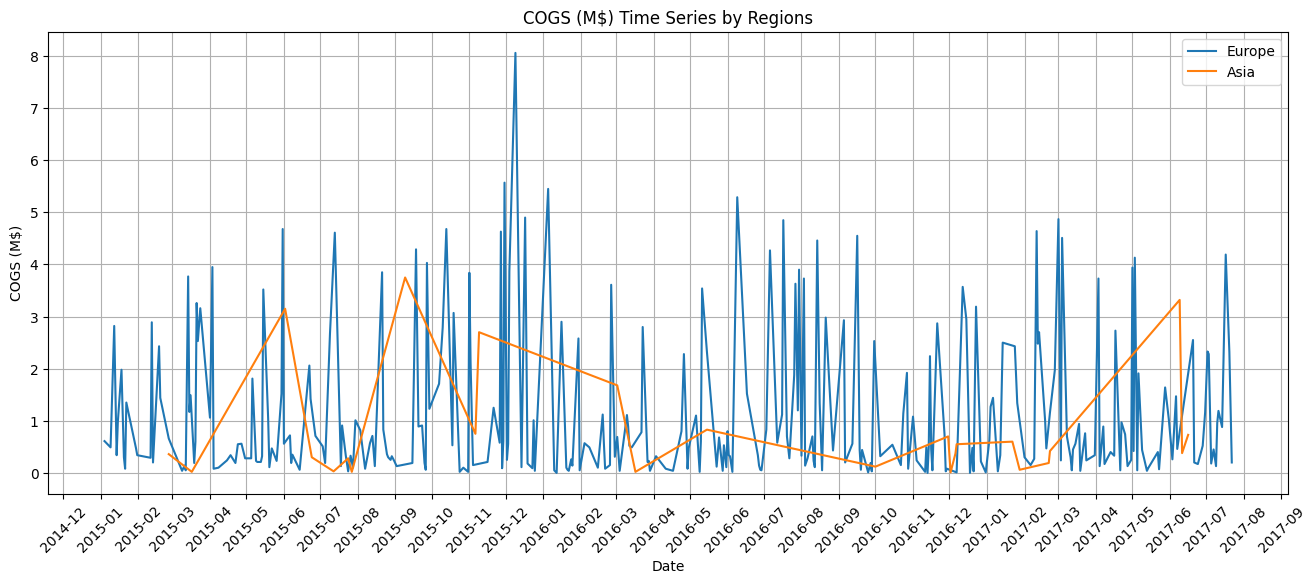

In [ ]:
cogs_by_regions_time_grouped = data_2015.groupby(["region", "order_date"])[["cogs"]].sum().sort_values(by="order_date").reset_index()

cogs_by_regions_time_grouped["cogs_m"] = round(cogs_by_regions_time_grouped["cogs"] / 1000000, 2)
cogs_by_regions_time_grouped = cogs_by_regions_time_grouped.drop(columns=["cogs"])

regions2 = cogs_by_regions_time_grouped["region"].unique()

plt.figure(figsize=(16, 6))
for region in regions2:
    region_data_2 = cogs_by_regions_time_grouped[cogs_by_regions_time_grouped["region"] == region]
    plt.plot(region_data_2["order_date"], region_data_2["cogs_m"], label=region)

ax = plt.gca()
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=1))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
plt.xticks(rotation=45)

plt.xlabel("Date")
plt.ylabel("COGS (M$)")
plt.title("COGS (M$) Time Series by Regions")
plt.legend()
plt.grid(True)
plt.show()

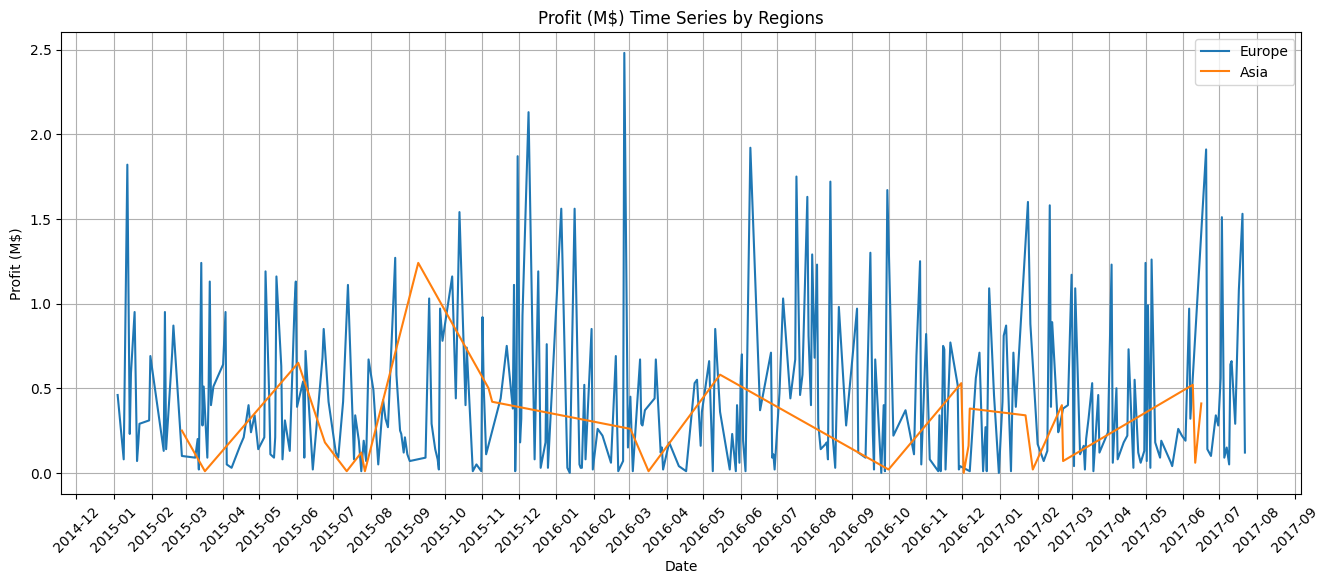

In [ ]:
profit_by_regions_time_grouped = data_2015.groupby(["region", "order_date"])[["profit"]].sum().sort_values(by="order_date").reset_index()

profit_by_regions_time_grouped["profit_m"] = round(profit_by_regions_time_grouped["profit"] / 1000000, 2)
profit_by_regions_time_grouped = profit_by_regions_time_grouped.drop(columns=["profit"])

regions3 = profit_by_regions_time_grouped["region"].unique()

plt.figure(figsize=(16, 6))
for region in regions3:
    region_data_3 = profit_by_regions_time_grouped[profit_by_regions_time_grouped["region"] == region]
    plt.plot(region_data_3["order_date"], region_data_3["profit_m"], label=region)

ax = plt.gca()
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=1))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
plt.xticks(rotation=45)

plt.xlabel("Date")
plt.ylabel("Profit (M$)")
plt.title("Profit (M$) Time Series by Regions")
plt.legend()
plt.grid(True)
plt.show()

Регіон **Європи** характеризується **високою волатильністю продажів**, з різкими великими піками та падіннями, деякі з яких наближаються ледь не до нуля. Це може свідчити про *тижневу сезонність*.

Цікаво, що **найвищий дохід** в цьому регіоні сягнув більше 10 млн дол. в першій половині **грудня 2015**, а **прибуток** - близько 2.5 млн дол. наприкінці **лютого 2016**, що демонструє деяку розбіжність патернів і необхідність вивчення її причин.

Аналіз попередніх графіків показав, що саме в період лютого **2016** різко **зросли продажі косметики, а ще більше - прибуток** від них. Сплеск доходів вкінці **2015** зумовлений **піком продажів канцелярського приладдя**.

В **Азії** також спостерігаються періодичні коливання, пов’язані з особливостями попиту в регіоні та ймовірними заходами з боку компанії.

# Аналіз продажів товарів за днями тижня

In [ ]:
# Загальний аналіз продажів товарів за днями тижня.

data["order_weekday"] = data["order_date"].dt.day_name()
data.head()

,order_id,order_date,ship_date,sales_channel,units_sold,unit_price,unit_cost,item_type,country,region,sub_region,sales,cogs,profit,days_diff,order_weekday
0,100640618,2014-10-08,2014-10-18,Online,650.0,205.70,117.11,Cereal,Norway,Europe,Northern Europe,133705.00,76121.50,57583.50,10,Wednesday
1,100983083,2016-08-11,2016-08-11,Offline,1993.0,205.70,117.11,Cereal,Serbia,Europe,Southern Europe,409960.10,233400.23,176559.87,0,Thursday
2,102230632,2017-05-13,2017-06-13,Online,1171.0,109.28,35.84,Clothes,Montenegro,Europe,Southern Europe,127966.88,41968.64,85998.24,31,Saturday
3,103435266,2012-08-11,2012-09-18,Offline,7648.0,47.45,31.79,Beverages,Serbia,Europe,Southern Europe,362897.60,243129.92,119767.68,38,Saturday
4,103450715,2015-03-15,2015-04-18,Online,2220.0,651.21,524.96,Office Supplies,Slovakia,Europe,Eastern Europe,1445686.20,1165411.20,280275.00,34,Sunday


In [ ]:
weekday_orders_counts = data.groupby("order_weekday")["order_id"].nunique().reset_index()

# правильний порядок днів
week_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
weekday_orders_counts["order_weekday"] = pd.Categorical(weekday_orders_counts["order_weekday"], categories=week_order, ordered=True)

weekday_orders_counts = weekday_orders_counts.sort_values("order_weekday")

weekday_orders_counts

,order_weekday,order_id
1,Monday,184
5,Tuesday,174
6,Wednesday,182
4,Thursday,158
0,Friday,163
2,Saturday,191
3,Sunday,194


In [ ]:
grouped_by_weekday = data.groupby("order_weekday")[["sales", "cogs", "profit"]].sum().reset_index()

grouped_by_weekday["sales_m"] = round(grouped_by_weekday["sales"] / 1000000, 2)
grouped_by_weekday["cogs_m"] = round(grouped_by_weekday["cogs"] / 1000000, 2)
grouped_by_weekday["profit_m"] = round(grouped_by_weekday["profit"] / 1000000, 2)
grouped_by_weekday = grouped_by_weekday.drop(columns=["sales", "cogs", "profit"])

grouped_by_weekday["order_weekday"] = pd.Categorical(grouped_by_weekday["order_weekday"], categories=week_order, ordered=True)
grouped_by_weekday = grouped_by_weekday.sort_values("order_weekday")

grouped_by_weekday

,order_weekday,sales_m,cogs_m,profit_m
1,Monday,259.16,187.00,72.16
5,Tuesday,204.87,141.35,63.51
6,Wednesday,244.87,177.10,67.77
4,Thursday,203.25,143.14,60.11
0,Friday,243.62,170.30,73.32
2,Saturday,220.82,152.08,68.74
3,Sunday,222.40,154.31,68.10


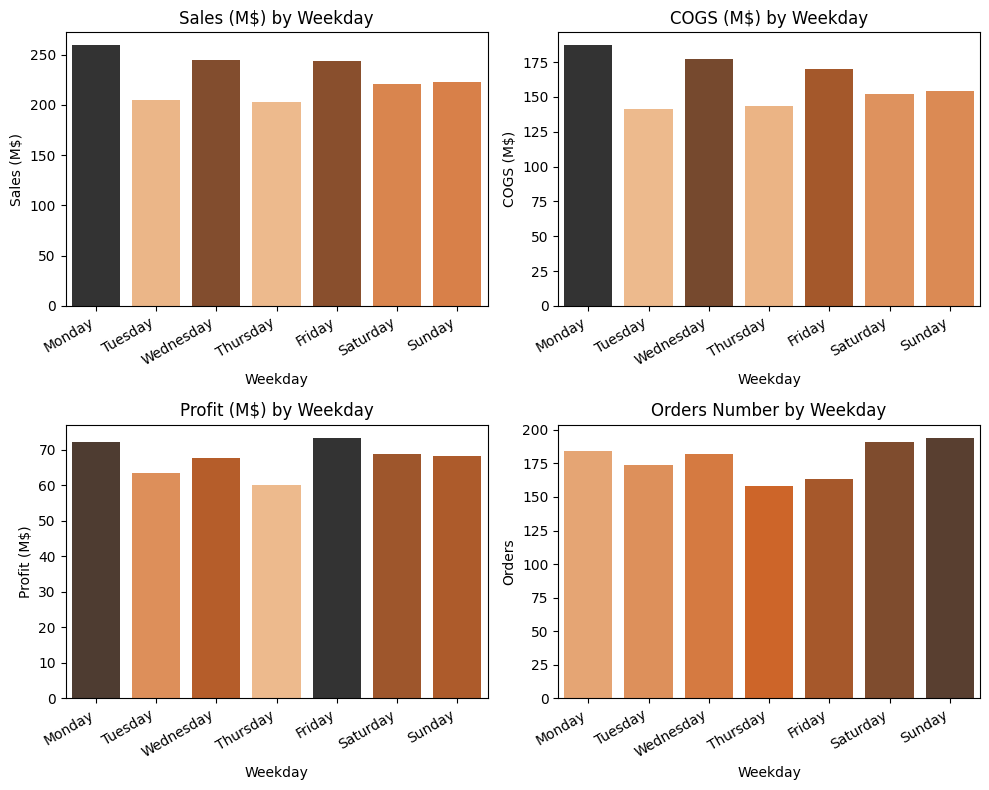

In [ ]:
fig, ax = plt.subplots(2, 2, figsize=(10, 8))

#orders by country
sns.barplot(data=weekday_orders_counts, y="order_id", x="order_weekday", palette="Oranges_d", hue="order_weekday", ax=ax[1,1], legend=False)
ax[1,1].set_title("Orders Number by Weekday")
ax[1,1].set_xlabel("Weekday")
ax[1,1].set_ylabel("Orders")

ax[1,1].tick_params(axis="x", labelrotation=30)
plt.setp(ax[1,1].get_xticklabels(), ha="right")

#sales by country
sns.barplot(data=grouped_by_weekday, y="sales_m", x="order_weekday", palette="Oranges_d", hue="sales_m", ax=ax[0,0], legend=False)
ax[0,0].set_title("Sales (M$) by Weekday")
ax[0,0].set_ylabel("Sales (M$)")
ax[0,0].set_xlabel("Weekday")

ax[0,0].tick_params(axis="x", labelrotation=30)
plt.setp(ax[0,0].get_xticklabels(), ha="right")

#cogs by country
sns.barplot(data=grouped_by_weekday, y="cogs_m", x="order_weekday", palette="Oranges_d", hue="cogs_m", ax=ax[0,1], legend=False)
ax[0,1].set_title("COGS (M$) by Weekday")
ax[0,1].set_ylabel("COGS (M$)")
ax[0,1].set_xlabel("Weekday")

ax[0,1].tick_params(axis="x", labelrotation=30)
plt.setp(ax[0,1].get_xticklabels(), ha="right")

#profit by country
sns.barplot(data=grouped_by_weekday, y="profit_m", x="order_weekday", palette="Oranges_d", hue="profit_m", ax=ax[1,0], legend=False)
ax[1,0].set_title("Profit (M$) by Weekday")
ax[1,0].set_ylabel("Profit (M$)")
ax[1,0].set_xlabel("Weekday")

ax[1,0].tick_params(axis="x", labelrotation=30)
plt.setp(ax[1,0].get_xticklabels(), ha="right")

plt.tight_layout()
plt.show()

Графіки показують: найбільше **продажів** (відповідно і витрат) генерується в **понеділок**.   

Найбільше **замовлень** припадає на **вихідні**, особливо на неділю.   

Проте найбільше **прибутку** генерує саме **п'ятниця**, хоч в цей день замовлення сягають майже найнижчого показника поряд із четвергом.

Вірогідно, це пов'язано з тим, що *в п'ятницю сягає пік замовлень косметики* (див. графік нижче), а саме ця категорія приносить компанії найбільші прибутки (див. аналіз продажів вище).

**Найменш** активними та прибутковими днями є вівторок і четвер.

In [ ]:
# Дослідження сезонності товарів за днями тижня

top_5_categories = data.groupby("item_type")["order_id"].nunique().sort_values(ascending=False).head(5).index
filtered_data = data[data["item_type"].isin(top_5_categories)]

weekday_category_orders_counts = filtered_data.groupby(["order_weekday", "item_type"])["order_id"].nunique().reset_index()

# правильний порядок днів
week_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
weekday_category_orders_counts["order_weekday"] = pd.Categorical(weekday_category_orders_counts["order_weekday"], categories=week_order, ordered=True)

weekday_category_orders_counts = weekday_category_orders_counts.sort_values("order_weekday")

weekday_category_orders_counts.head()

,order_weekday,item_type,order_id
9,Monday,Personal Care,10
5,Monday,Baby Food,16
6,Monday,Beverages,18
7,Monday,Cosmetics,12
8,Monday,Office Supplies,14


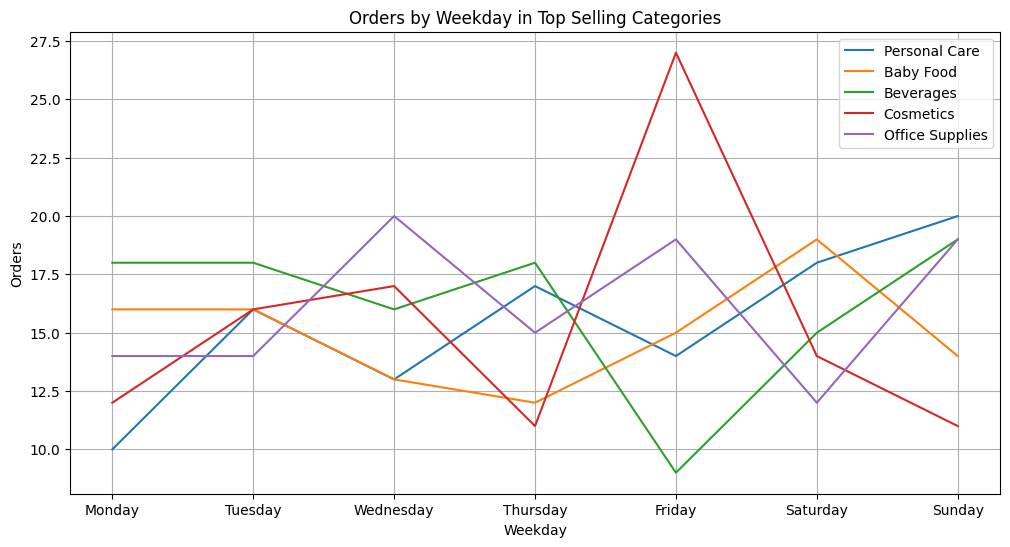

In [ ]:
categories = weekday_category_orders_counts["item_type"].unique()

plt.figure(figsize=(12, 6))
for category in categories:
    categories_data = weekday_category_orders_counts[weekday_category_orders_counts["item_type"] == category]
    plt.plot(categories_data["order_weekday"], categories_data["order_id"], label=category)

plt.xlabel("Weekday")
plt.ylabel("Orders")
plt.title("Orders by Weekday in Top Selling Categories")
plt.legend()
plt.grid(True)
plt.show()

Чітко виражену **сезонність** демонструє **косметика**: на п'ятницю припадає пік кількості замовлень товарів цієї категорії (близько 27).

На противагу, продажі напоїв в п'ятницю є найменшими (близько 5), при цьому в інші дні тижня характеризуються відносною стабільністю (15-19 замовлень)

#Ключові висновки

1) **Попит і виручка не тотожні**: велика кількість замовлень не завжди означає високі фінансові результати.

Найчастіше замовляють канцелярське приладдя, напої та косметику. Однак напої демонструють низькі показники доходу та прибутку, що свідчить про низьку маржинальність категорії.

2) **Товари для дому** - **фінансово сильна** категорія. Попри низьку частоту замовлень, ця категорія займає друге місце за доходом, витратами та прибутком, що вказує на вищий середній чек.

3) **Косметика - основне джерело прибутку** завдяки відносно низькій собівартості. Це робить цю категорію стратегічно важливою для компанії.

4) **Чехія** забезпечує найбільший дохід, але має низьку прибутковість (7 місце за прибутком).

**Андорра та Україна** демонструють високу прибутковість при відносно меншій або середній кількості замовлень.

Це вказує на суттєві відмінності в товарній структурі замовлень та маржі.

5) Найкращі фінансові показники - у **Південній Європі**. Західна Європа має найменшу кількість замовлень, а Азія демонструє мінімальну купівельну активність, обмежену Західною Азією.

6) **Популярність каналу продажу** (онлайн / офлайн) **залежить від категорій**. Offline: дитяче харчування, канцелярське приладдя, догляд за собою, фрукти.
Online: їжа та напої, одяг, товари для дому.

7) **Тривалість виконання замовлення не впливає на прибуток напряму**, однак окремі країни (Угорщина, Грузія, Австрія, Словаччина) мають найдовші строки відвантаження, що потребує операційного аудиту логістичних процесів.

8) **Продажі залежать від дня тижня.**
* Понеділок - максимум доходів і витрат.
* Вихідні - пік кількості замовлень.
* П’ятниця - день найвищого прибутку при відносно низькій кількості замовлень, що пояснюється зростанням продажів косметики.
* Найменш активні та прибуткові дні - вівторок і четвер.

**Отже**, компанії слід, замість обсягів замовлень, фокусуватися на просуванні найбільш прибуткових категорій, з урахуванням сезонності та активності споживачів. Також варто оптимізувати логістику в країнах з аномальними строками відвантаження.